In [3]:
from curl_cffi import requests
import yfinance as yf 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib as ta
import seaborn as sns
sns.set_theme(style="whitegrid")
import pickle
import duckdb as db
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay

In [4]:
with open('../../data/enhanced_trades_df_v2.pkl', 'rb') as f:
    df = pickle.load(f)

In [5]:
df

,Symbol,entry_date,entry_price,exit_date,exit_price,return,Close,stock_ret_1d,rsi,adx,...,volatility_of_volatility,dsv,vol_z,vol_vol_ratio,obv_z,vwap_dev,result,Industry,hmm_cluster,Industry_woe
2396,NMDC,2016-03-09,13.149165,2016-04-28,13.738341,4.480711,13.149165,-0.015344,75.574806,33.866604,...,0.004685,0.000438,-0.943376,13.231202,1.863594,0.137517,1,Metals & Mining,0.0,0.171921
1419,HINDALCO,2016-03-21,80.699150,2016-03-30,82.575851,2.325553,80.699150,0.009390,66.985118,30.847063,...,0.004331,0.000358,-0.152065,33.855358,0.968967,0.063425,1,Metals & Mining,3.0,0.171921
3240,TATASTEEL,2016-03-21,22.325666,2016-05-05,24.403414,9.306541,22.325666,0.004467,73.931740,30.156950,...,0.008066,0.000155,-0.579234,35.126138,1.071643,0.016532,1,Metals & Mining,3.0,0.171921
598,BHARTIARTL,2016-03-22,299.554504,2016-04-01,286.365204,-4.402972,299.554504,-0.007776,68.502922,30.521119,...,0.002222,0.000175,0.457509,83.115273,1.333358,0.015242,0,Telecommunication,3.0,-0.170878
2815,RELIANCE,2016-03-22,229.608643,2016-03-28,223.593719,-2.619641,229.608643,0.010171,67.560319,30.172319,...,0.002951,0.000280,0.116702,80.890779,1.781608,0.113989,0,Oil Gas & Consumable Fuels,3.0,0.041870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1692,INDIGO,2025-08-27,6050.000000,2025-08-28,5727.000000,-5.338843,6050.000000,0.000000,57.705115,30.314948,...,0.000636,0.000106,3.992301,603.398978,0.451727,0.000000,0,Services,1.0,-0.240706
3580,VMM,2025-08-27,153.139999,2025-09-02,146.330002,-4.446910,153.139999,0.000000,68.060884,31.580026,...,0.001744,0.000392,1.153450,218.252956,2.544196,0.000000,0,Consumer Services,1.0,0.189966
3360,TITAN,2025-08-29,3628.800049,2025-09-15,3534.100098,-2.609677,3628.800049,-0.002447,64.093506,31.060234,...,0.001865,0.000062,-0.379968,97.851273,1.078735,0.072640,0,Consumer Durables,1.0,0.183092
2209,MFSL,2025-08-29,1602.199951,2025-09-04,1566.000000,-2.259390,1602.199951,-0.004041,53.859737,30.395963,...,0.001349,0.000116,-0.450856,49.298656,0.452576,-0.124731,0,Financial Services,1.0,-0.029508


In [4]:
df.columns

Index(['Symbol', 'entry_date', 'entry_price', 'exit_date', 'exit_price',
       'return', 'Close', 'stock_ret_1d', 'rsi_14', 'adx_14', 'Index_Close',
       'index_ret_1d', 'index_ret_5d', 'index_ret_20d', 'index_vol',
       'index_vol_5d', 'index_vol_20d', 'plus_di', 'minus_di', 'rsi_5_chg',
       'adx_5_chg', 'roc_5', 'rsi_14_chg', 'adx_14_chg', 'roc_14',
       'rsi_30_chg', 'adx_30_chg', 'roc_30', 'atr_5', 'atr_14', 'atr_30',
       'vol_5d', '5_days_high', 'vol_14d', '14_days_high', 'vol_30d',
       '30_days_high', 'macd', 'macd_signal', 'macd_hist', 'rel_ret', 'beta',
       'corr', 'stock_vol', 'excess_vol', 'gk_vol', 'vol_of_vol', 'skew',
       'kurt', 'dsv', 'vol_z', 'vol_vol_ratio', 'obv_z', 'vwap_dev', 'result',
       'Industry', 'kmeans_cluster', 'hmm_cluster', 'Industry_woe'],
      dtype='object')

In [5]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
entry_date,3669,2020-12-18 03:34:17.563368704,2016-03-09 00:00:00,2018-08-27 00:00:00,2021-01-19 00:00:00,2023-05-16 00:00:00,2025-09-09 00:00:00,NaN
entry_price,3669.0,1915.539551,3.94832,174.261047,538.509338,1389.445923,150485.734375,7228.501953
exit_date,3669,2021-01-14 00:23:09.370400768,2016-03-28 00:00:00,2018-09-11 00:00:00,2021-02-23 00:00:00,2023-06-23 00:00:00,2025-09-15 00:00:00,NaN
exit_price,3669.0,1947.426514,4.131962,178.804352,550.106873,1392.53186,144285.0,7416.228027
return,3669.0,2.615062,-68.927544,-3.666073,-1.060605,3.622118,359.561768,15.743247
Close,3669.0,1915.539551,3.94832,174.261047,538.509338,1389.445923,150485.734375,7228.501953
stock_ret_1d,3669.0,0.011918,-0.123968,-0.003245,0.007282,0.022058,0.2,0.025918
Index_Close,3669.0,15065.112333,7531.799805,10728.849609,14507.299805,18534.099609,26216.050781,5077.197864
index_ret_1d,3669.0,0.002235,-0.037636,-0.002422,0.002099,0.00685,0.053191,0.007716
index_vol,3669.0,0.008029,0.003169,0.005757,0.007039,0.009308,0.055956,0.004153


In [6]:
df.isnull().sum()

Symbol            0
entry_date        0
entry_price       0
exit_date         0
exit_price        0
                 ..
result            0
Industry          0
kmeans_cluster    0
hmm_cluster       0
Industry_woe      0
Length: 61, dtype: int64

In [5]:
columns = ['stock_ret_1d', 'index_ret_1d',
       'index_vol', 'ema_9_ratio', 'ema_30_ratio', 'ema_100_ratio', 'plus_di',
       'minus_di', 'adx', 'rsi', 'roc_3', 'roc_7', 'roc_14', 'roc_30', 'atr_3',
       'atr_7', 'atr_14', 'atr_30', 'stock_ret_3d', 'stock_ret_7d',
       'stock_ret_14d', 'stock_ret_30d', 'vol_3d', 'vol_7d', 'vol_14d',
       'vol_30d', '3_days_high', '7_days_high', '14_days_high', '30_days_high',
       'macd', 'macd_signal', 'macd_hist', 'rel_ret', 'beta', 'corr',
       'stock_vol', 'excess_vol', 'parkinson_vol', 'gk_vol', 'vol_of_vol',
       'skew', 'kurt', 'dsv', 'vol_z', 'vol_vol_ratio', 'obv_z', 'vwap_dev', 'Industry_woe']
# len(columns) 49

# plot boxplots for all columns

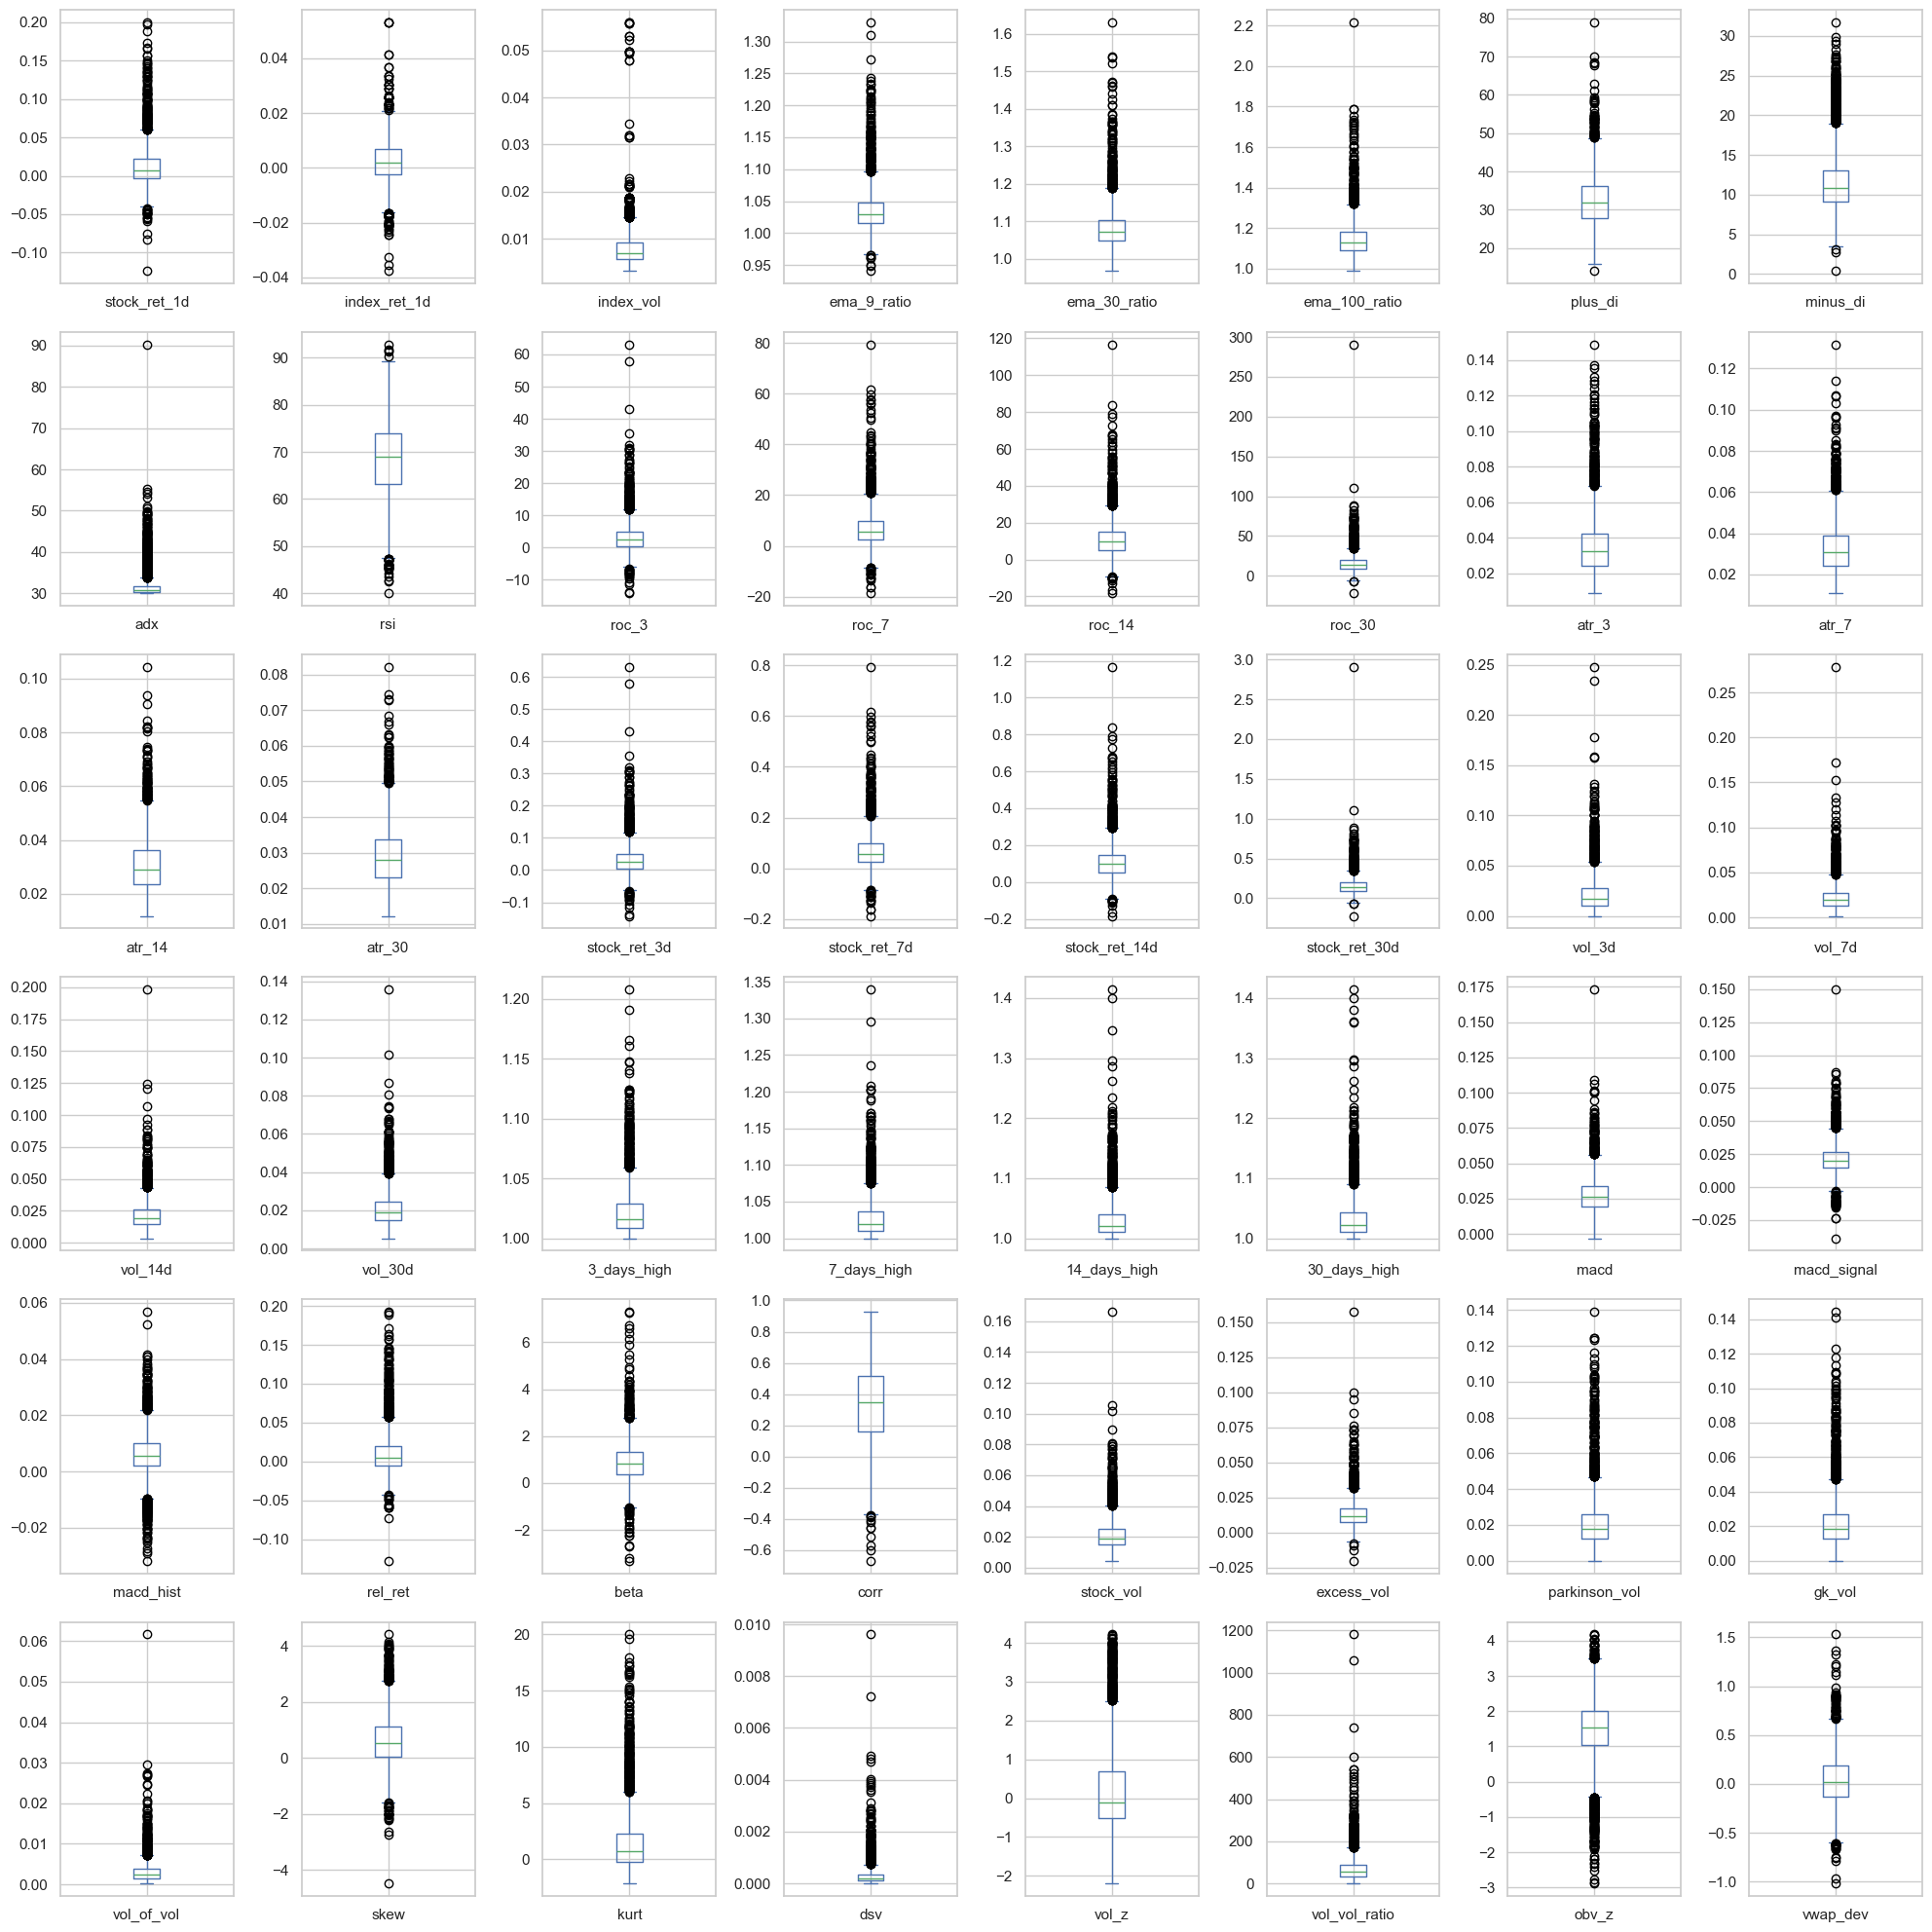

In [ ]:
df[columns].plot(kind='box', subplots=True, layout=(7,8), figsize=(20,20))
plt.tight_layout()

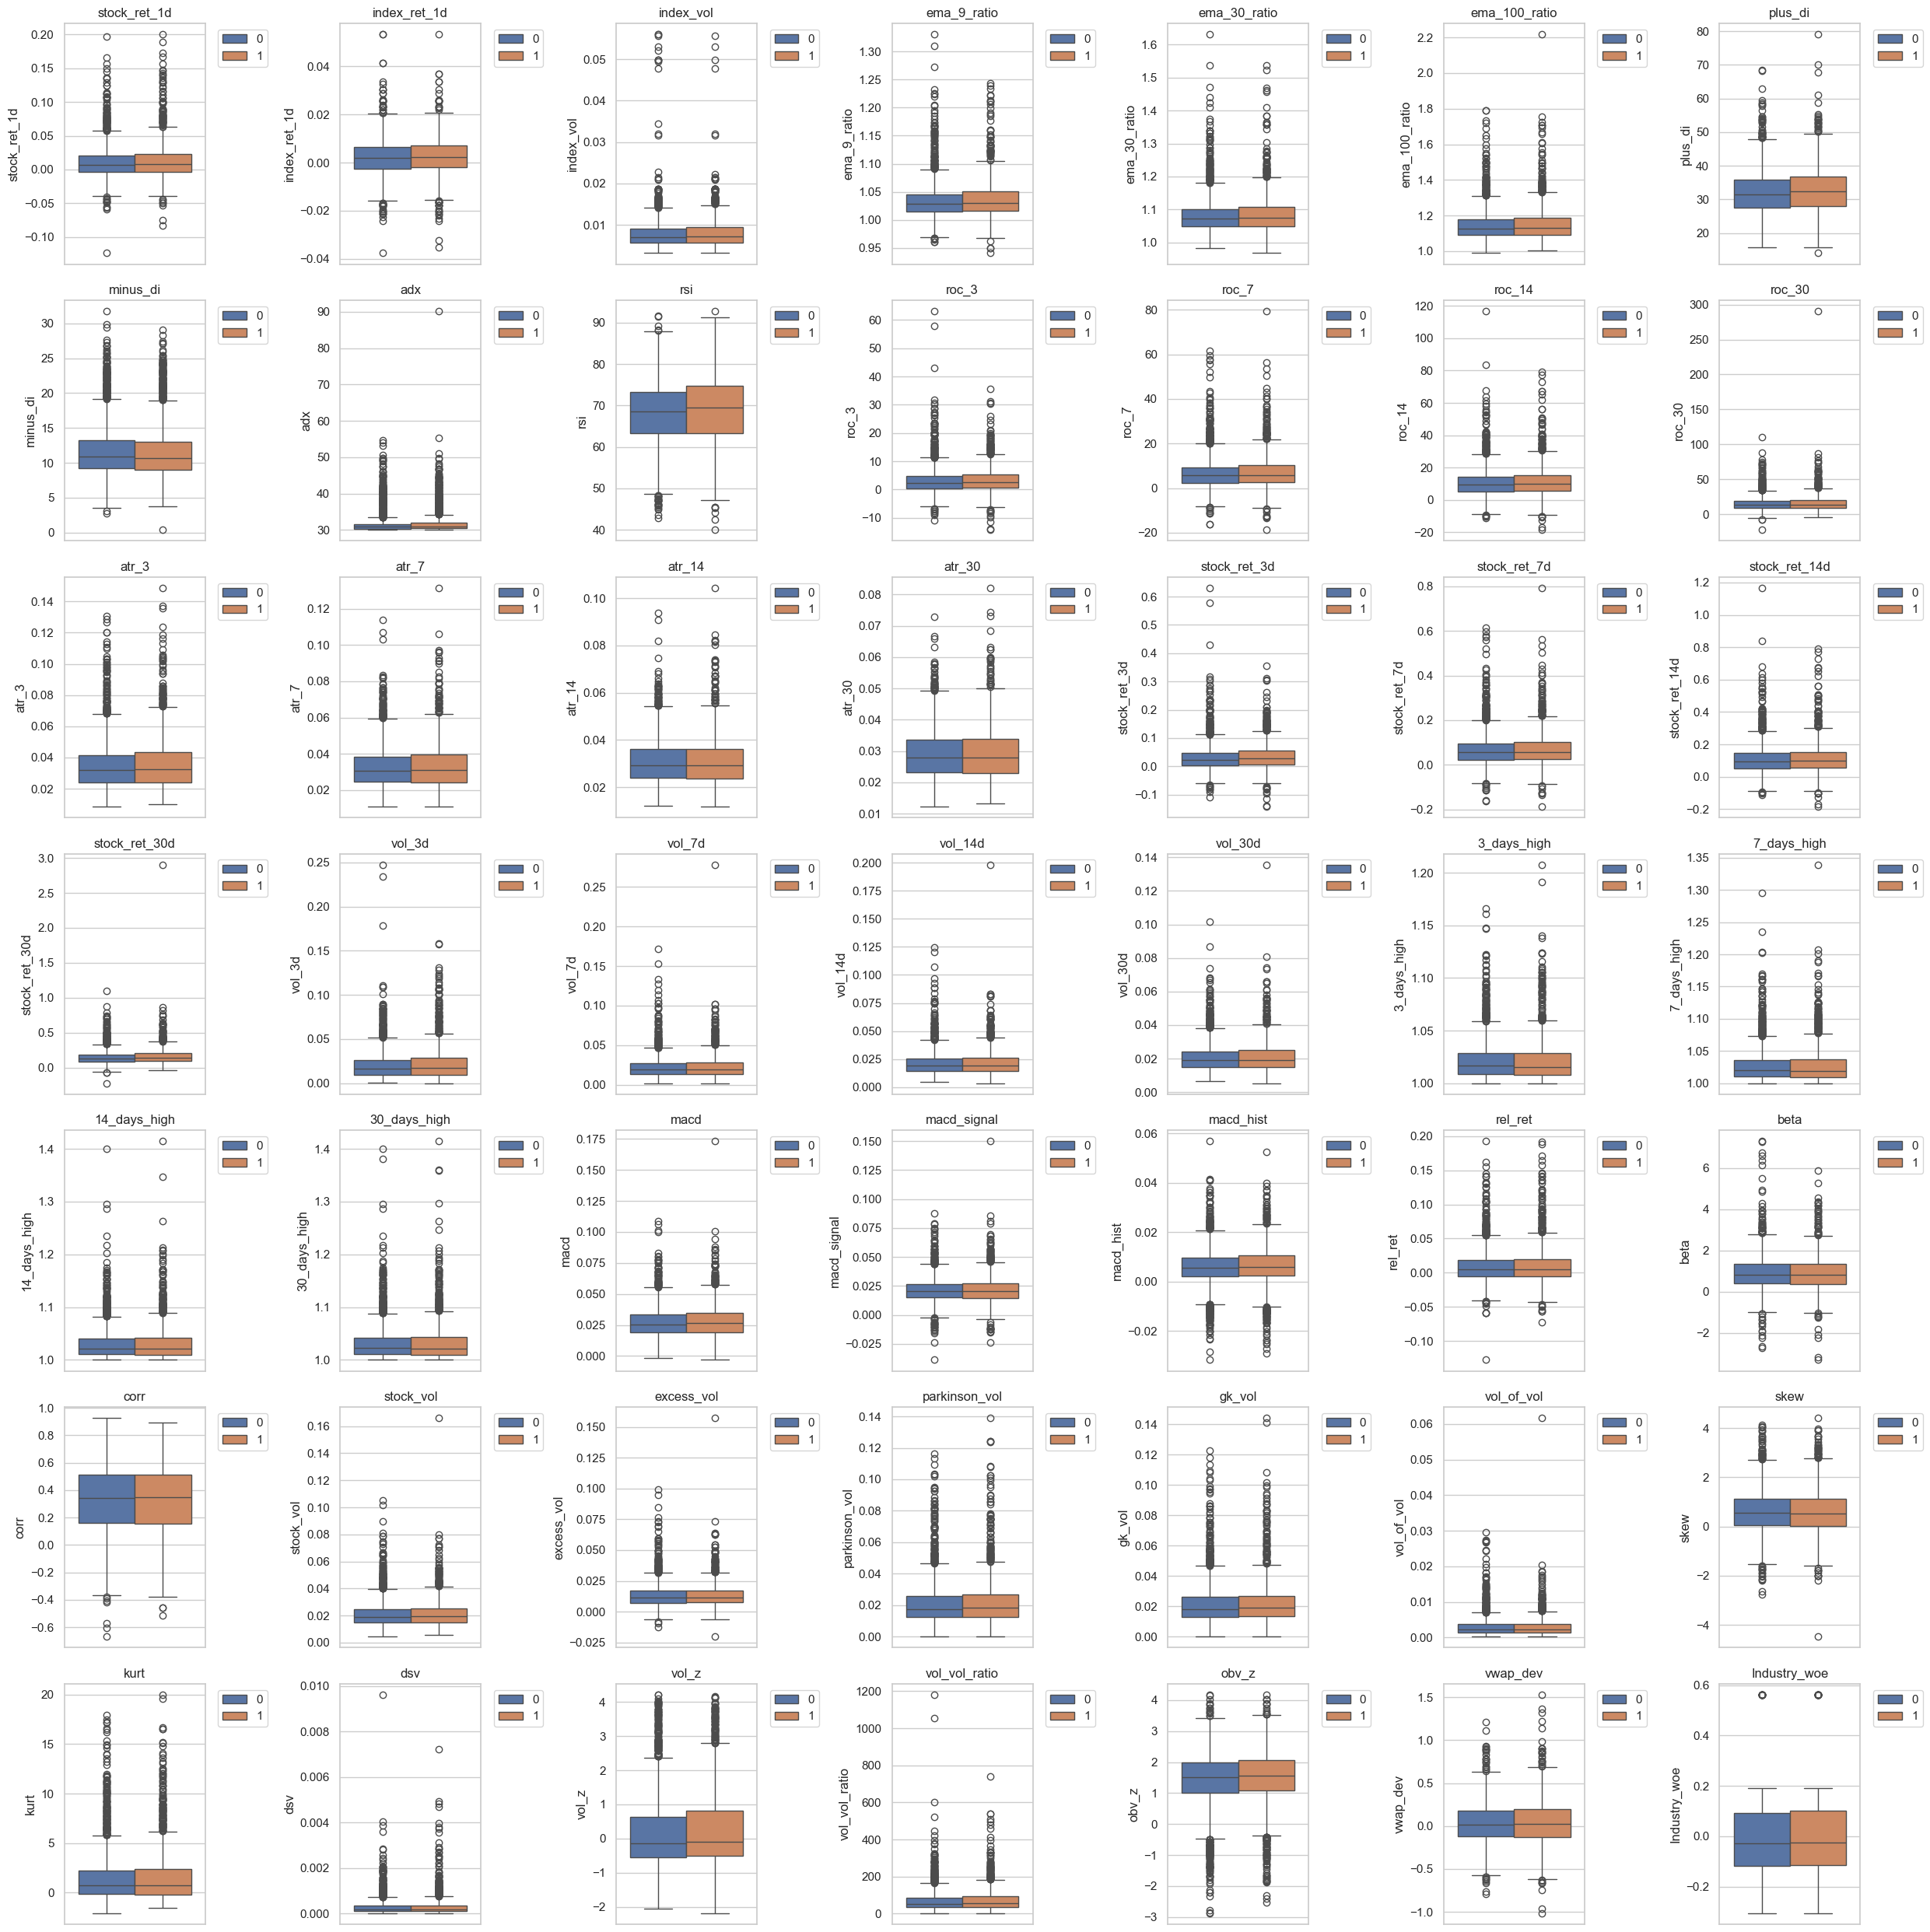

In [68]:
fig, axes = plt.subplots(7, 7, figsize=(25, 25))
axes = axes.flatten()

# Assuming you have a categorical column for hue (replace 'your_hue_column' with actual column name)
hue_column = 'result'  # or whatever categorical column you want to use for hue

for i, col in enumerate(columns):
    if i < len(axes):
        sns.boxplot(data=df, y=col, hue=hue_column, ax=axes[i])
        axes[i].set_title(col)
        axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [69]:
# clean dataset by keeping rows with values within 5% and 95% quantile for each column
for col in columns:
    lower_bound = df[col].quantile(0.05)
    upper_bound = df[col].quantile(0.95)
    df_trunc = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [70]:
df_trunc = df_trunc.reset_index(drop=True)

In [71]:
df_trunc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 61 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Symbol          3479 non-null   object        
 1   entry_date      3479 non-null   datetime64[ns]
 2   entry_price     3479 non-null   float32       
 3   exit_date       3479 non-null   datetime64[ns]
 4   exit_price      3479 non-null   float32       
 5   return          3479 non-null   float32       
 6   Close           3479 non-null   float32       
 7   stock_ret_1d    3479 non-null   float32       
 8   Index_Close     3479 non-null   float64       
 9   index_ret_1d    3479 non-null   float64       
 10  index_vol       3479 non-null   float64       
 11  ema_9_ratio     3479 non-null   float64       
 12  ema_30_ratio    3479 non-null   float64       
 13  ema_100_ratio   3479 non-null   float64       
 14  plus_di         3479 non-null   float64       
 15  minu

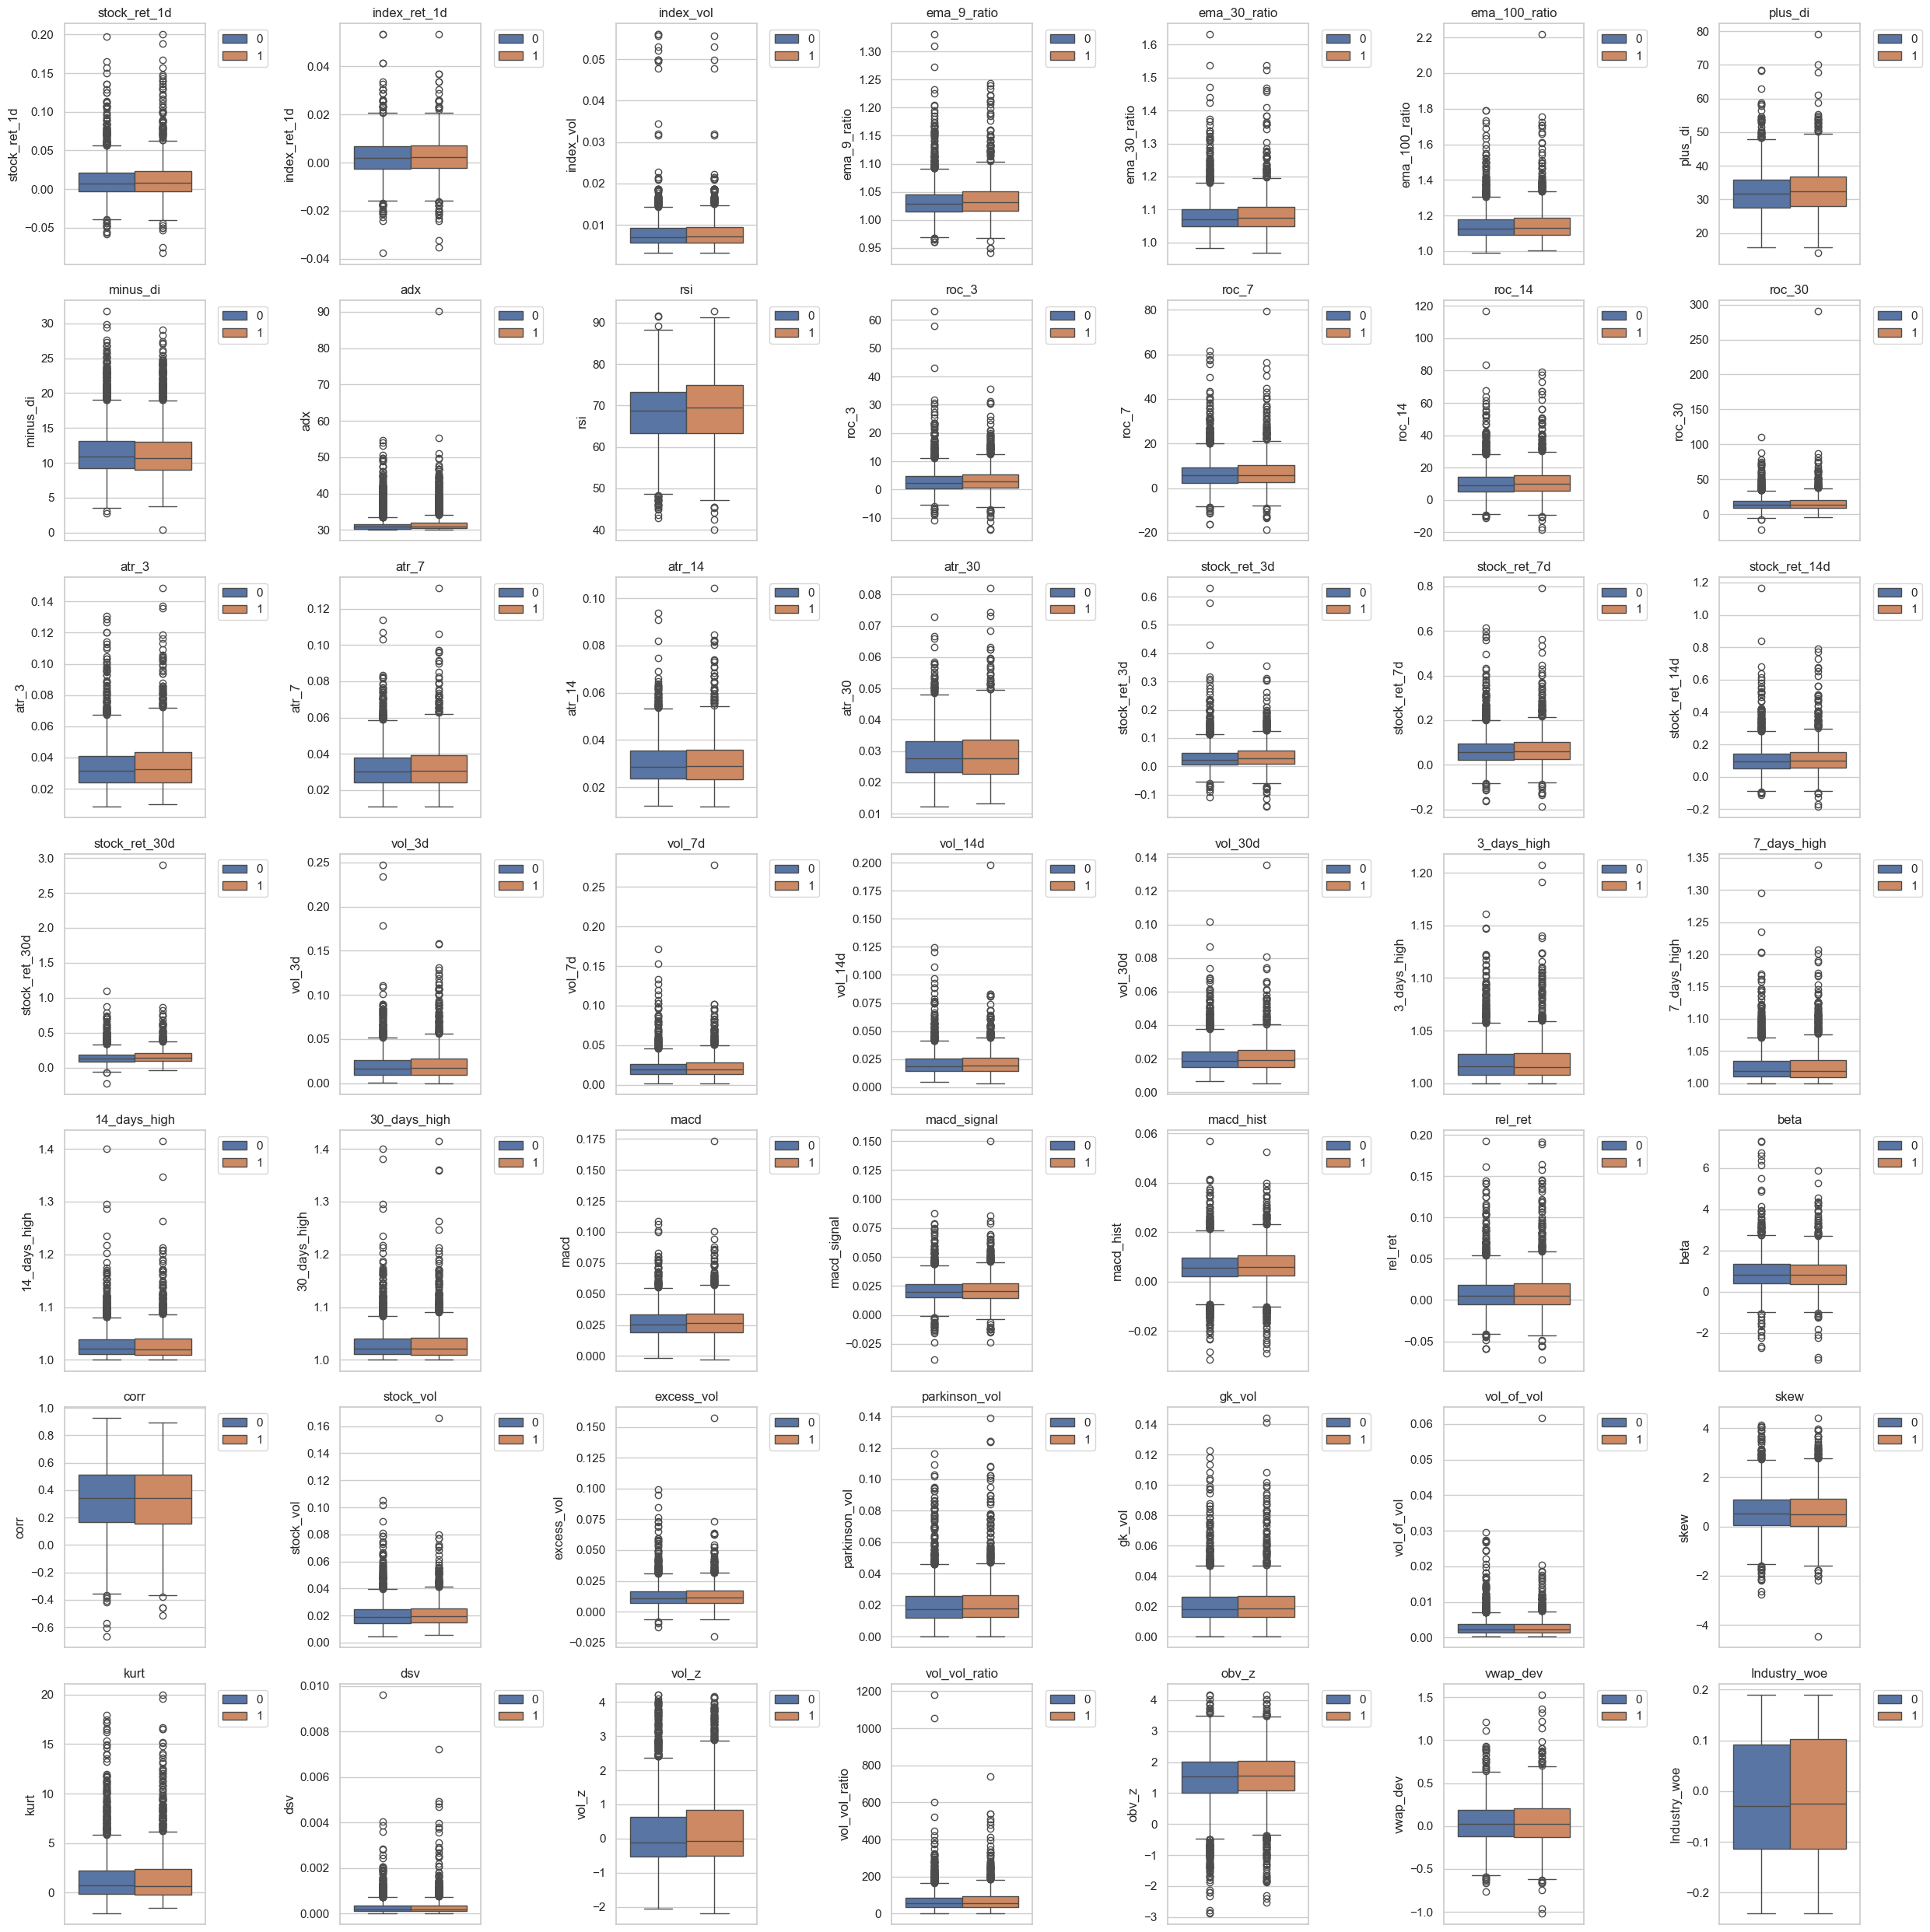

In [72]:
fig, axes = plt.subplots(7, 7, figsize=(25, 25))
axes = axes.flatten()

# Assuming you have a categorical column for hue (replace 'your_hue_column' with actual column name)
hue_column = 'result'  # or whatever categorical column you want to use for hue

for i, col in enumerate(columns):
    if i < len(axes):
        sns.boxplot(data=df_trunc, y=col, hue=hue_column, ax=axes[i])
        axes[i].set_title(col)
        axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

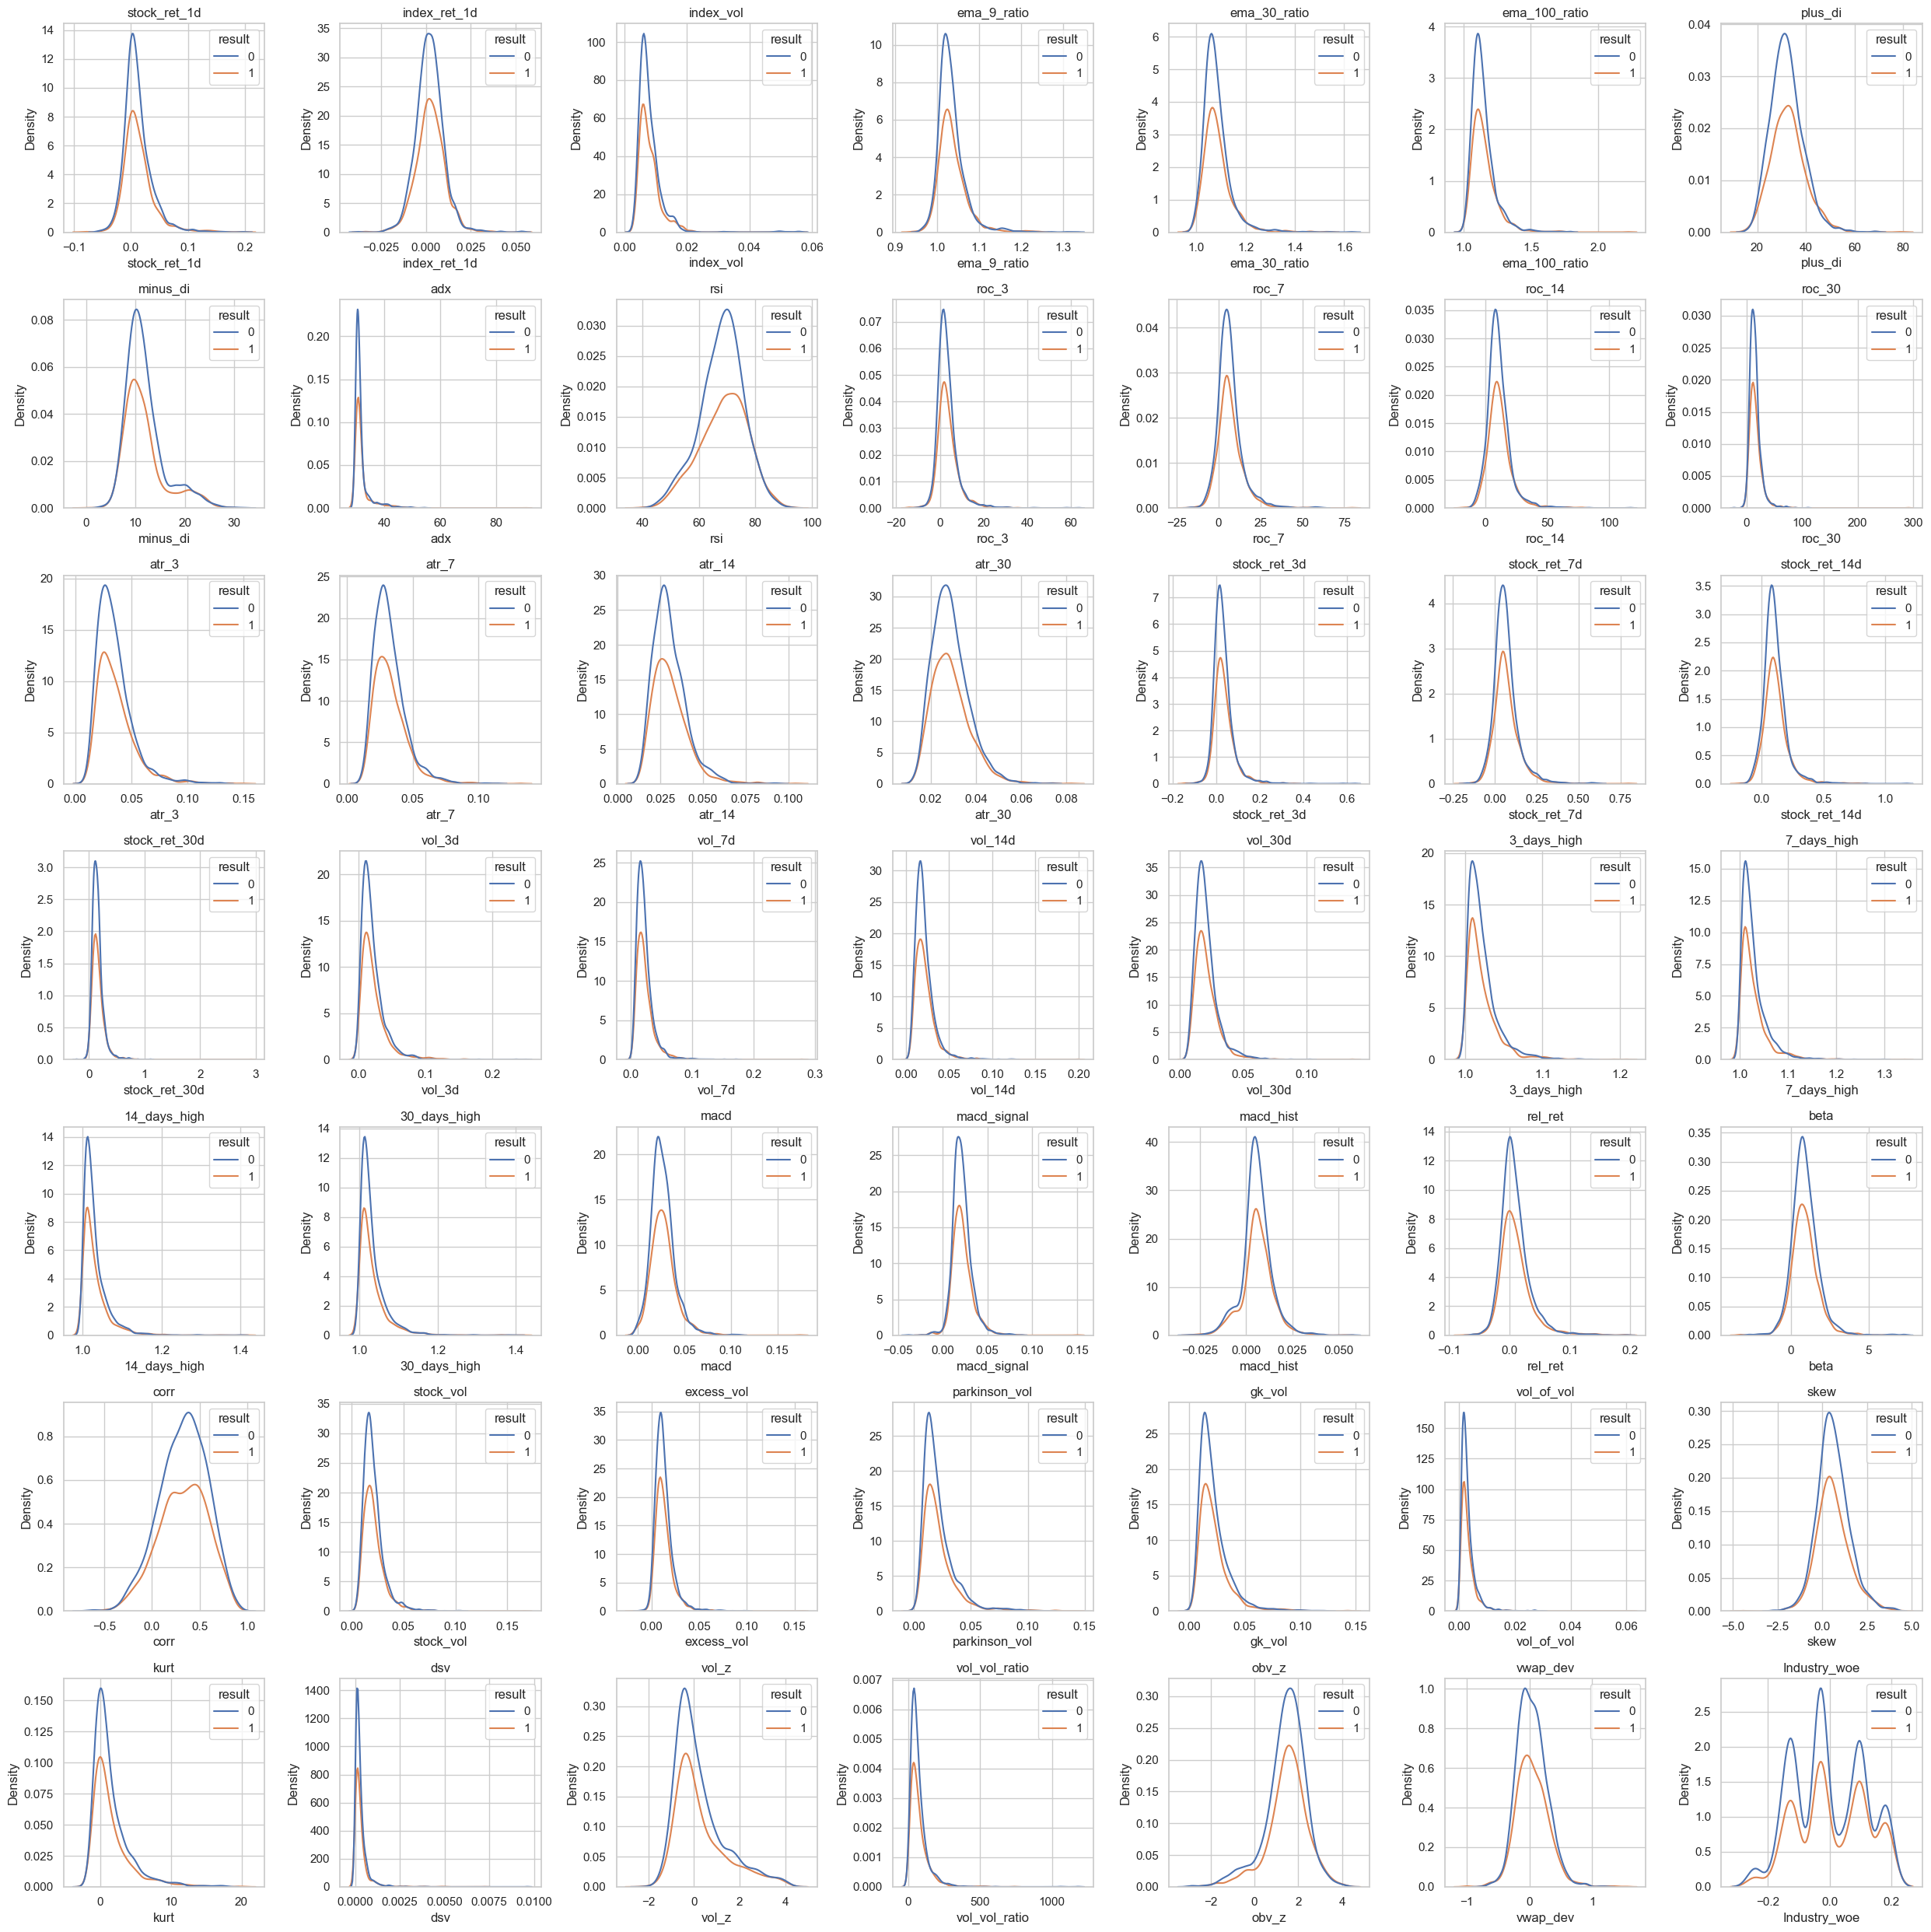

In [73]:
fig, axes = plt.subplots(7, 7, figsize=(25, 25))
axes = axes.flatten()

# Assuming you have a categorical column for hue (replace 'your_hue_column' with actual column name)
hue_column = 'result'  # or whatever categorical column you want to use for hue

for i, col in enumerate(columns):
    if i < len(axes):
        sns.kdeplot(data=df_trunc, x=col, hue=hue_column, ax=axes[i])
        axes[i].set_title(col)
        # axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [74]:
sc = StandardScaler()
df_scaled = sc.fit_transform(df_trunc[columns])

In [75]:
columns

['stock_ret_1d',
 'index_ret_1d',
 'index_vol',
 'ema_9_ratio',
 'ema_30_ratio',
 'ema_100_ratio',
 'plus_di',
 'minus_di',
 'adx',
 'rsi',
 'roc_3',
 'roc_7',
 'roc_14',
 'roc_30',
 'atr_3',
 'atr_7',
 'atr_14',
 'atr_30',
 'stock_ret_3d',
 'stock_ret_7d',
 'stock_ret_14d',
 'stock_ret_30d',
 'vol_3d',
 'vol_7d',
 'vol_14d',
 'vol_30d',
 '3_days_high',
 '7_days_high',
 '14_days_high',
 '30_days_high',
 'macd',
 'macd_signal',
 'macd_hist',
 'rel_ret',
 'beta',
 'corr',
 'stock_vol',
 'excess_vol',
 'parkinson_vol',
 'gk_vol',
 'vol_of_vol',
 'skew',
 'kurt',
 'dsv',
 'vol_z',
 'vol_vol_ratio',
 'obv_z',
 'vwap_dev',
 'Industry_woe']

In [76]:
pca = PCA()
df_pca=pca.fit_transform(df_scaled)

Text(0, 0.5, 'Cumulative Explained Variance')

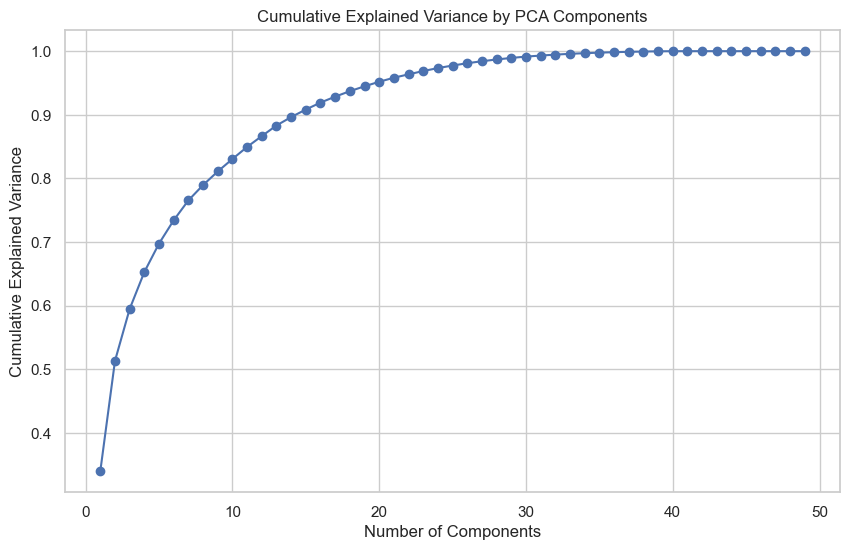

In [77]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')


In [78]:
# get first 30 components
df_pca_30 = pd.DataFrame(df_pca[:, :30], columns=[f'PC{i+1}' for i in range(30)])
df_pca_30["result"] = df_trunc["result"]
df_pca_30

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,result
0,1.418960,-1.373316,0.033018,-0.145976,-1.058148,-0.295160,-1.023537,-1.126337,0.208097,1.164579,...,-0.019032,0.118019,0.543115,-0.395288,0.072909,-0.439985,-0.429593,-0.575316,0.327986,0
1,2.600967,-4.112418,-0.224267,-0.120557,-0.358635,0.612352,-1.343079,0.051073,1.397364,-0.533279,...,-0.073455,0.507988,-0.125304,-0.066957,0.252936,0.062723,-0.392977,-0.042558,0.089615,1
2,-0.937966,-2.756113,2.080277,2.244764,1.292225,0.717743,0.797547,0.485630,0.718769,1.042964,...,-0.637927,0.602038,0.231782,0.423700,0.112834,-0.252787,-0.182201,-0.029876,-0.028194,0
3,-2.672803,2.003984,1.043987,-0.005238,0.451024,0.525720,0.332963,-0.049733,0.209693,-0.023648,...,-0.542980,0.301826,-0.479446,0.428635,-0.133665,-0.326556,0.052800,-0.104776,0.242184,1
4,-3.140710,0.142067,-1.439430,1.420664,-0.610783,0.362179,-0.495799,-0.783013,0.783841,0.251486,...,0.157867,0.198321,-0.327772,0.094121,-0.291923,-0.128097,-0.079474,-0.201745,0.266100,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3474,-2.862140,-3.326013,2.322268,1.435050,-0.993161,2.134359,0.009098,0.409401,-1.618026,0.509714,...,0.009566,1.047753,0.508852,0.263755,-0.141227,0.213863,-0.261480,-0.087723,0.408512,1
3475,-2.842717,-2.562145,-0.473354,0.696864,-0.304497,0.373105,-1.023364,-0.334988,-0.494903,-0.755621,...,0.521980,0.186886,-0.019803,0.111418,-0.052922,0.087543,0.111051,-0.037787,0.172068,1
3476,-5.529193,3.616380,0.437349,-0.560434,-0.075333,0.502910,0.832733,0.546663,0.052414,-1.882470,...,-0.382611,0.084013,-0.791839,0.132239,-0.442118,0.447779,0.183887,-0.297164,0.006022,0
3477,-2.926571,0.011184,-0.027831,3.847061,0.756714,-1.783580,0.647396,0.441335,0.382550,-0.644154,...,-0.327501,0.066891,-0.021306,0.446769,-0.774236,-0.005901,-0.011061,0.410764,-0.092597,1


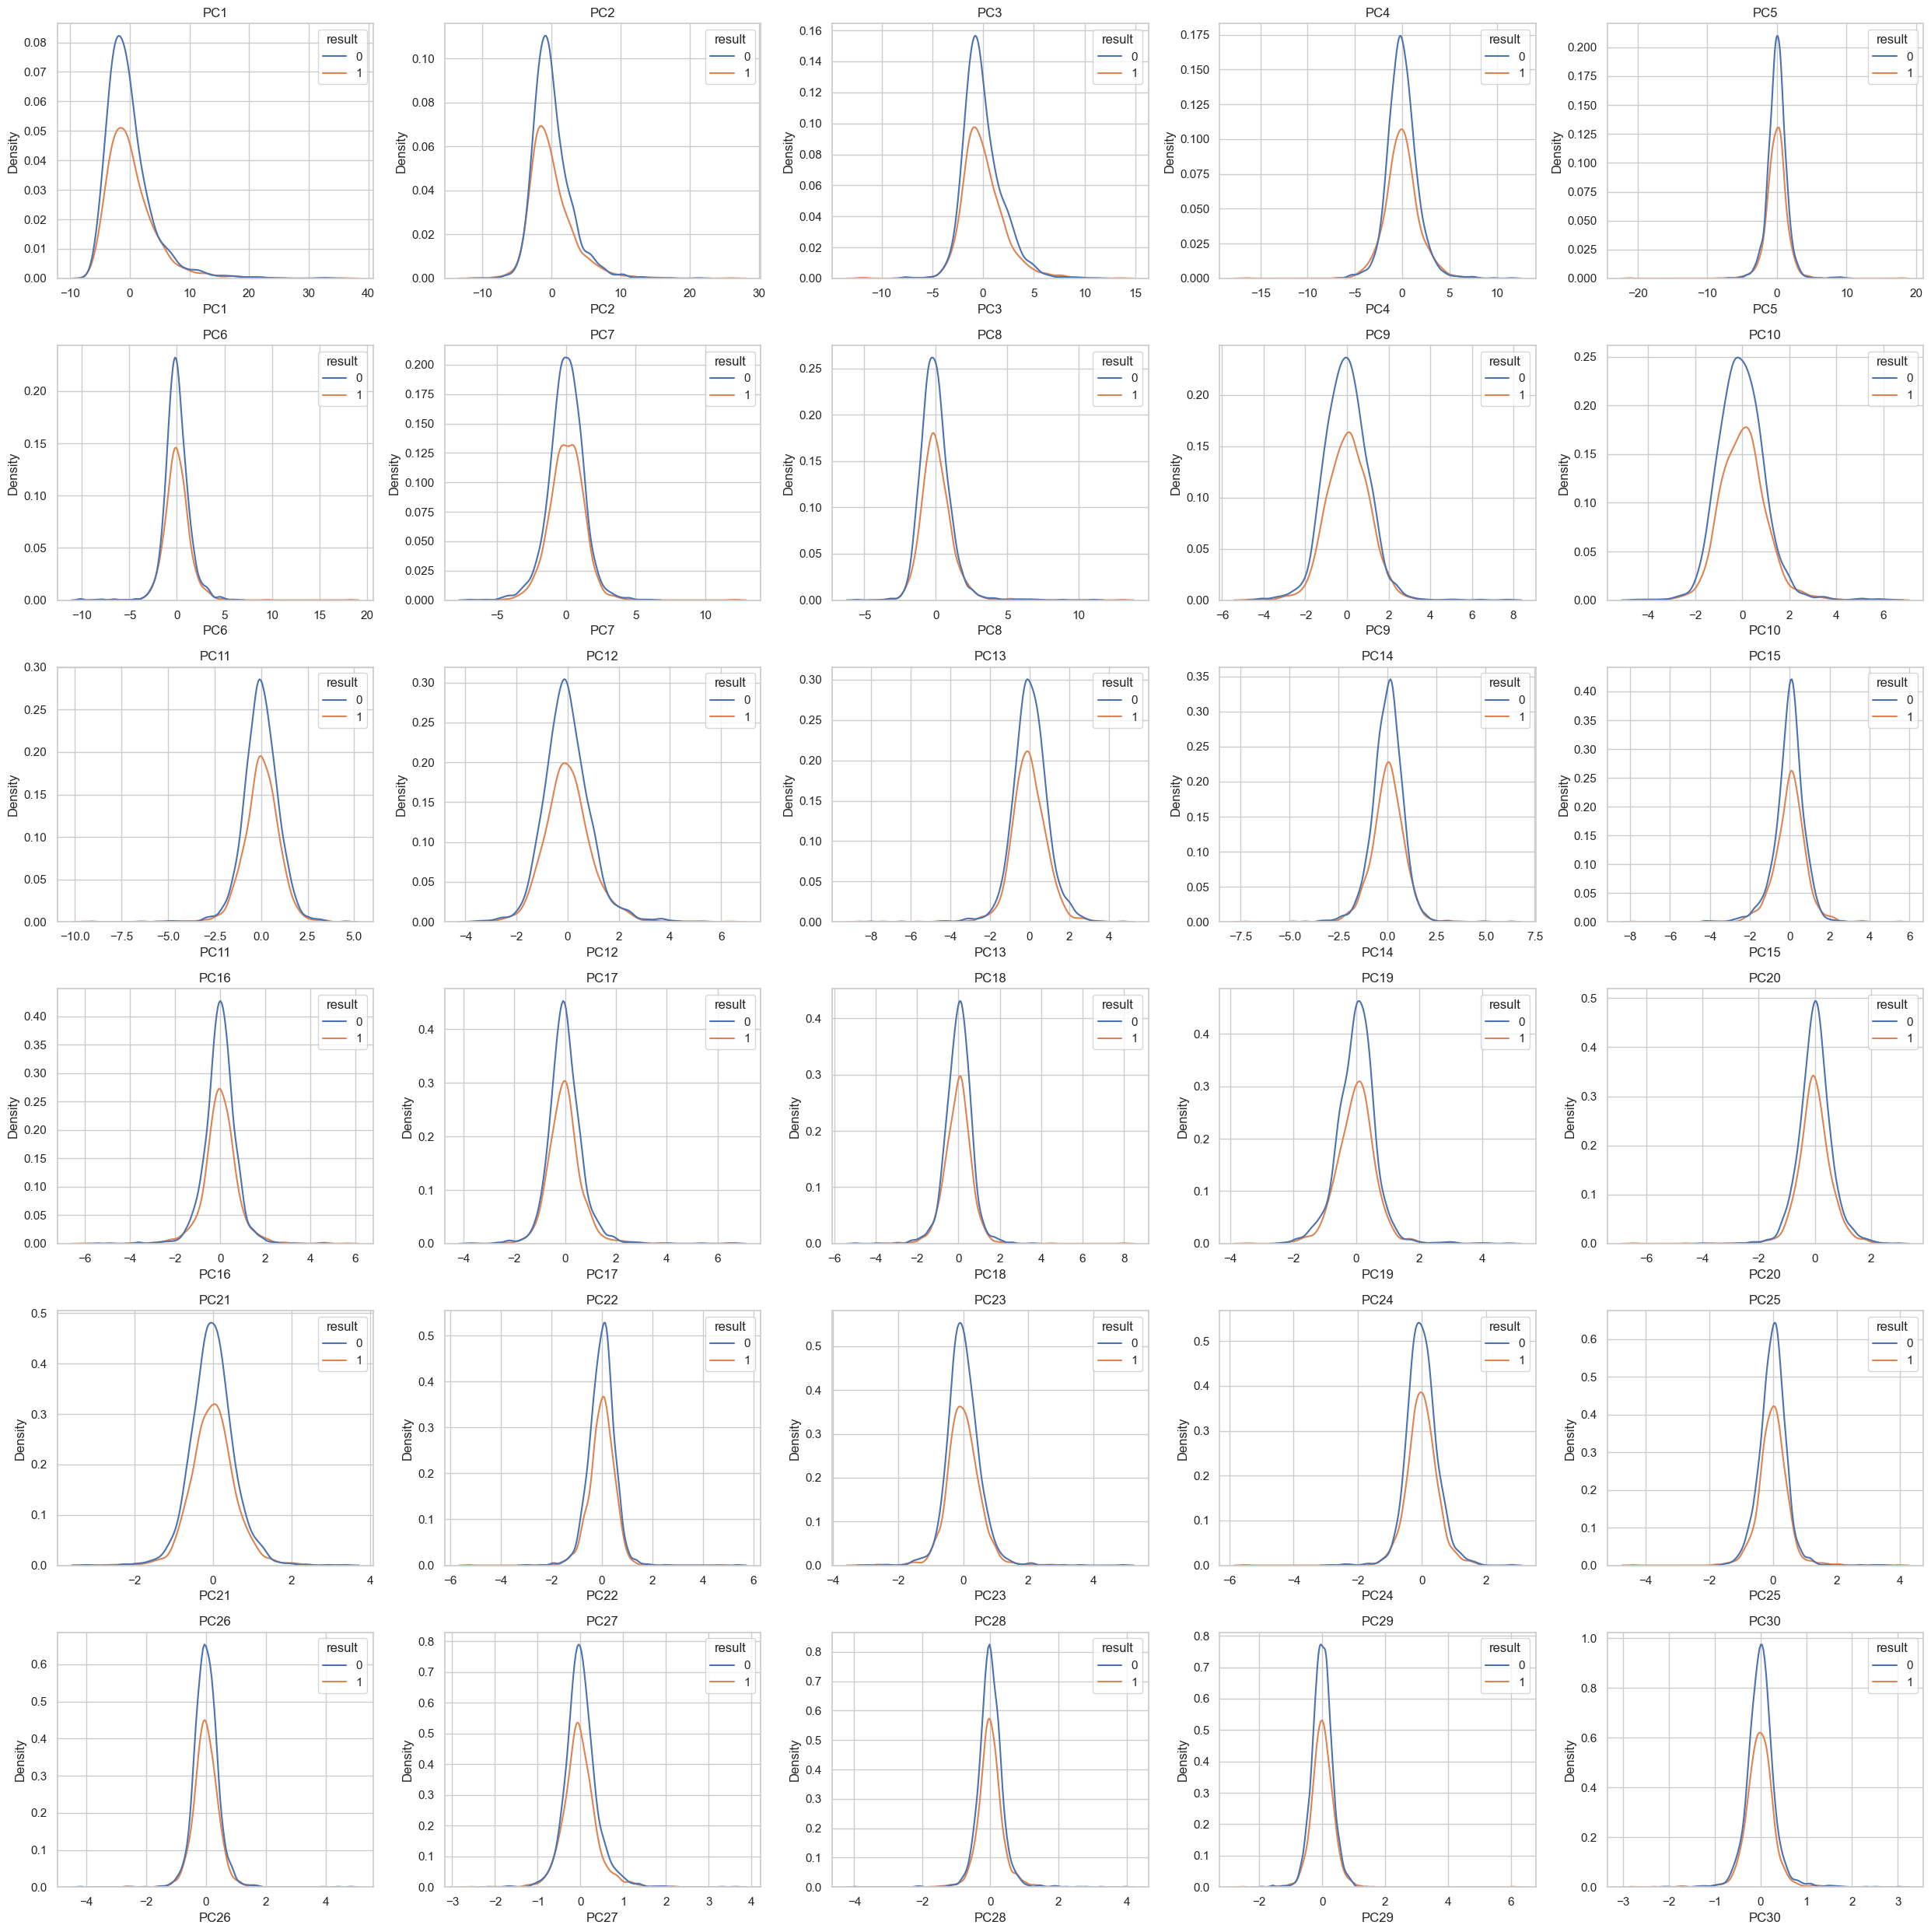

In [79]:
fig, axes = plt.subplots(6, 5, figsize=(25, 25))
axes = axes.flatten()

# Assuming you have a categorical column for hue (replace 'your_hue_column' with actual column name)
hue_column = 'result'  # or whatever categorical column you want to use for hue

for i, col in enumerate(df_pca_30.columns[:-1]):
    if i < len(axes):
        sns.kdeplot(data=df_pca_30, x=col, hue=hue_column, ax=axes[i])
        axes[i].set_title(col)
        # axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

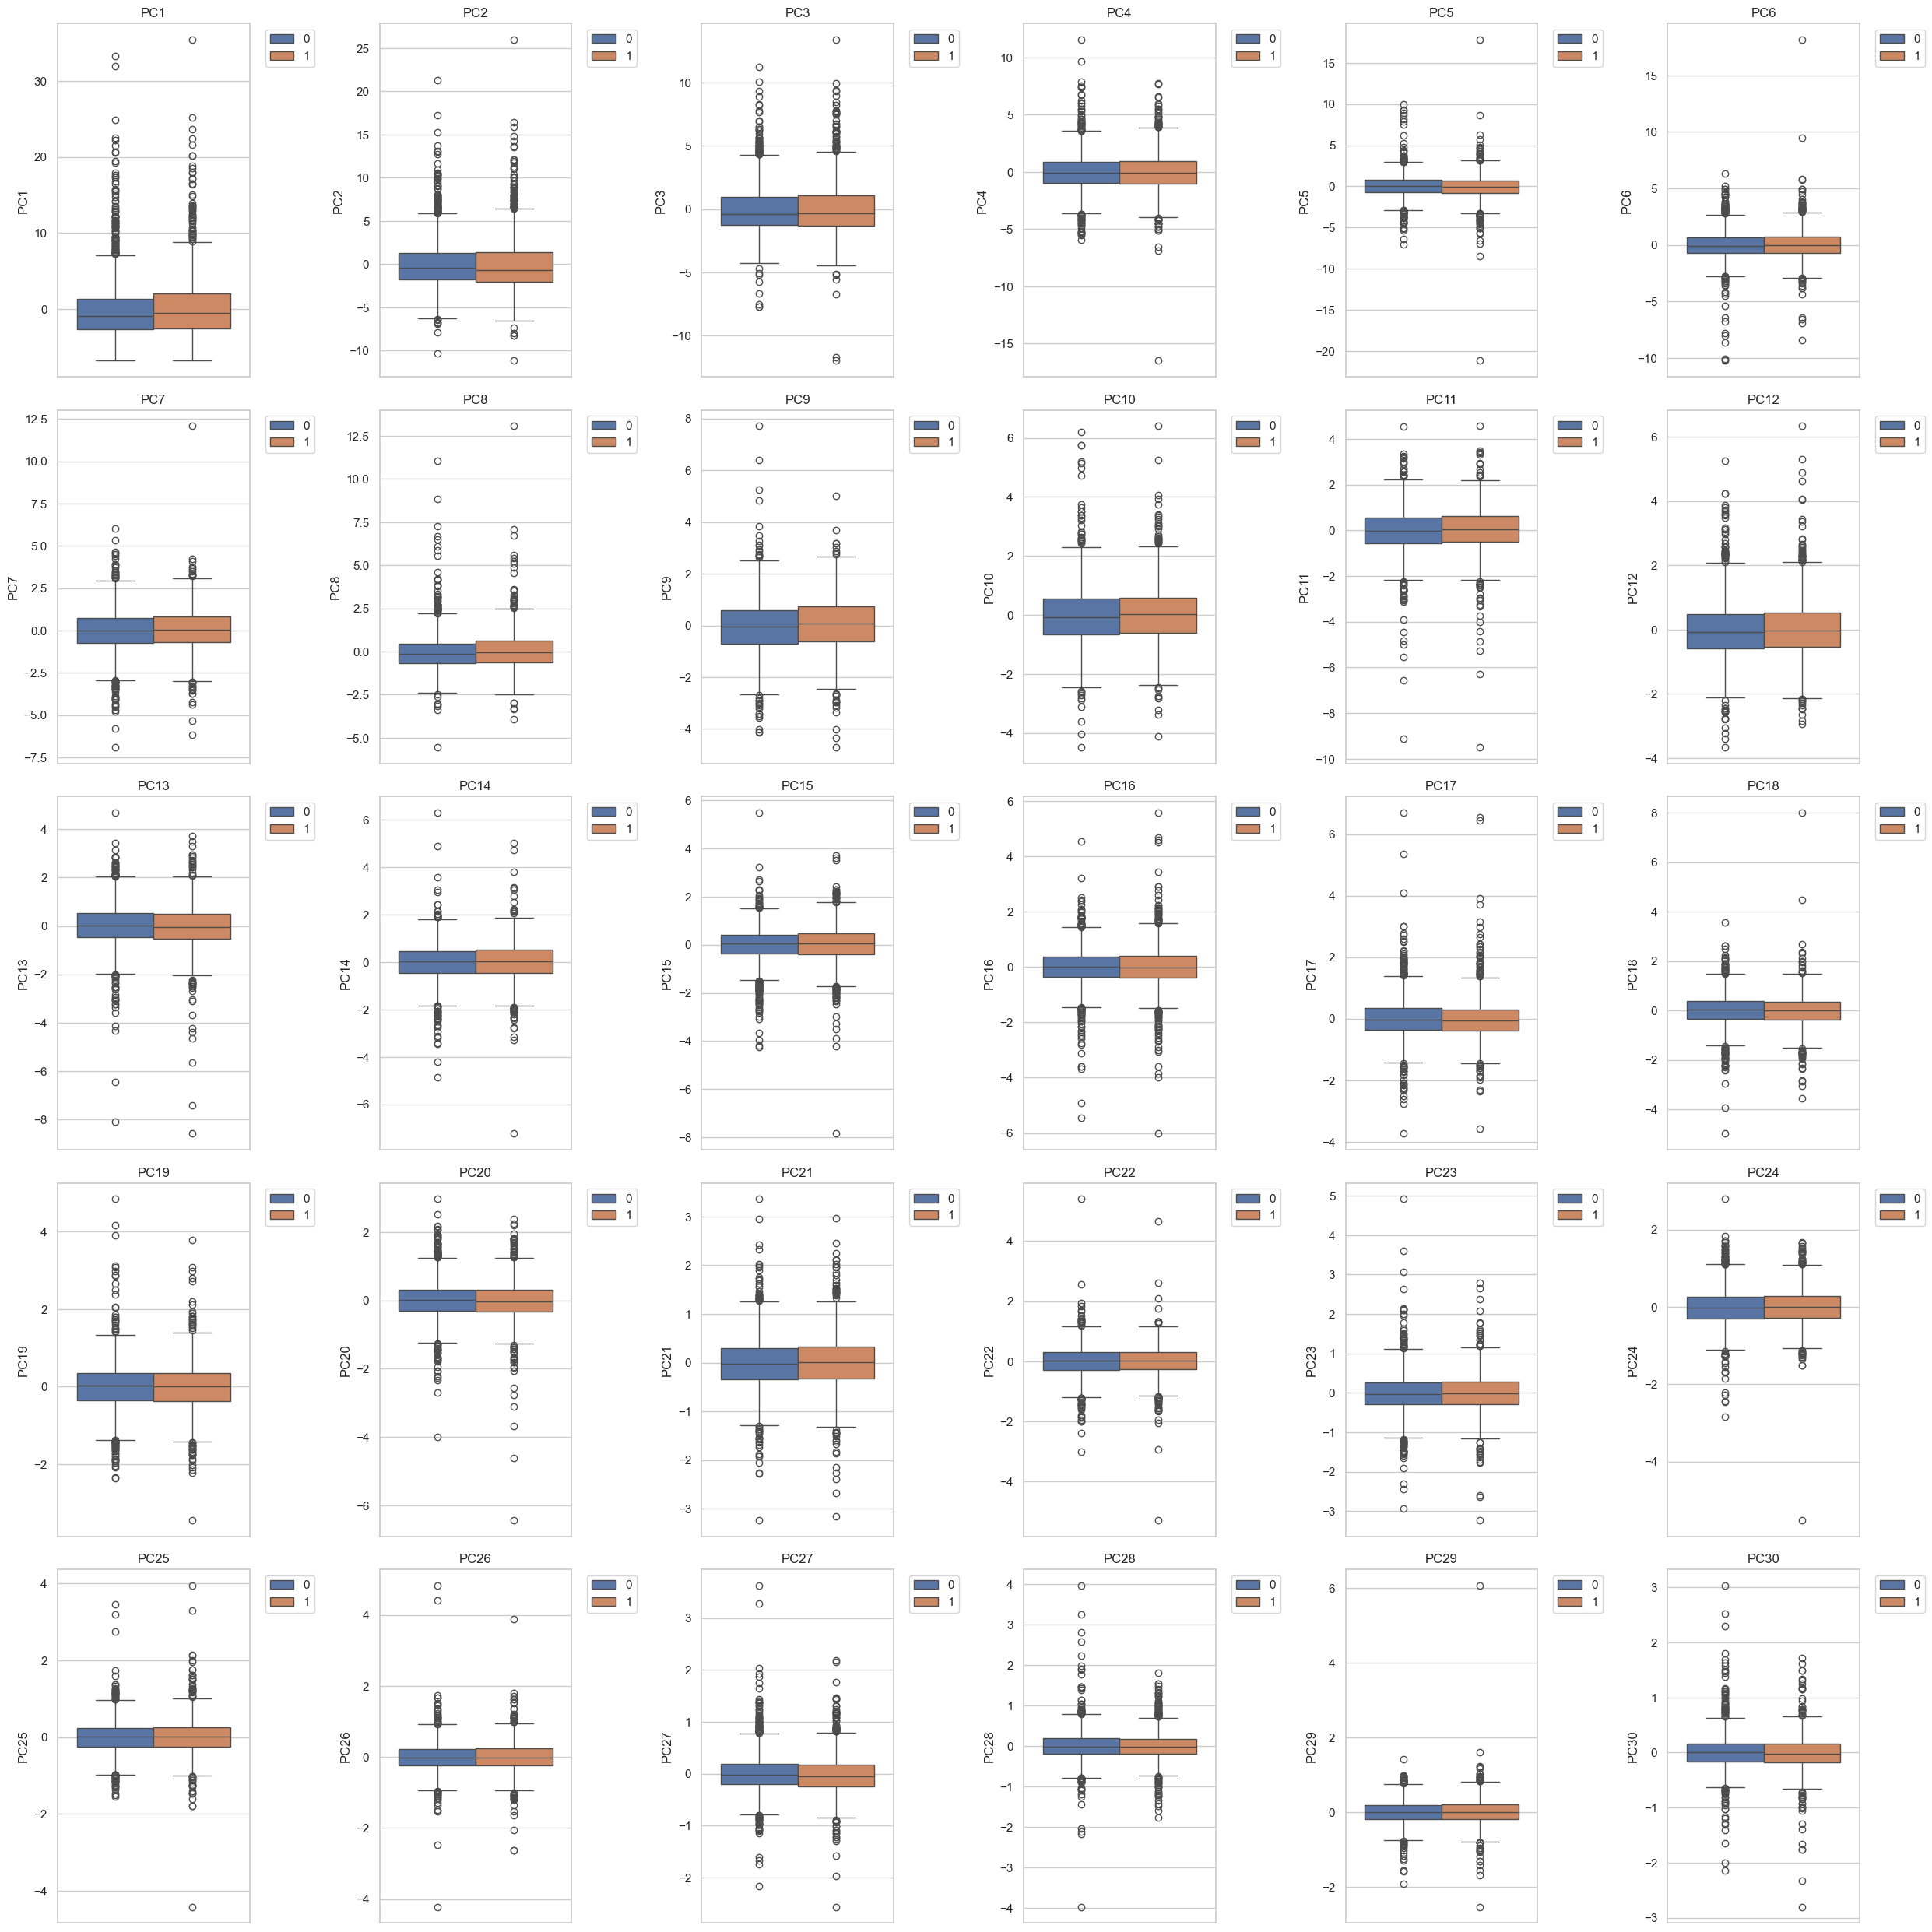

In [80]:
fig, axes = plt.subplots(5, 6, figsize=(25, 25))
axes = axes.flatten()

# Assuming you have a categorical column for hue (replace 'your_hue_column' with actual column name)
hue_column = 'result'  # or whatever categorical column you want to use for hue

for i, col in enumerate(df_pca_30.columns[:-1]):
    if i < len(axes):
        sns.boxplot(data=df_pca_30, y=col, hue=hue_column, ax=axes[i])
        axes[i].set_title(col)
        axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [81]:
df.head()

,Symbol,entry_date,entry_price,exit_date,exit_price,return,Close,stock_ret_1d,Index_Close,index_ret_1d,...,dsv,vol_z,vol_vol_ratio,obv_z,vwap_dev,result,Industry,kmeans_cluster,hmm_cluster,Industry_woe
0,ABB,2016-04-01,1130.375488,2016-05-04,1072.873291,-5.087000,1130.375488,0.009983,7713.049805,-0.003276,...,0.000249,1.528192,78.290163,2.057573,0.066625,0,Capital Goods,2.0,1.0,0.092264
1,ABB,2017-04-11,1267.503418,2017-05-23,1273.588867,0.480113,1267.503418,0.029695,9237.000000,0.006050,...,0.000101,-0.244947,71.118903,2.087195,0.314671,1,Capital Goods,2.0,0.0,0.092264
2,ABB,2018-01-15,1330.367676,2018-02-19,1306.259766,-1.812124,1330.367676,0.025037,10741.549805,0.005645,...,0.000050,1.770258,192.689483,2.686783,0.220293,0,Capital Goods,2.0,0.0,0.092264
3,ABB,2018-09-06,1142.333374,2018-10-03,1253.569824,9.737652,1142.333374,0.021961,11536.900391,0.005224,...,0.000115,-0.088891,78.644890,0.792242,0.116395,1,Capital Goods,2.0,0.0,0.092264
4,ABB,2019-04-10,1217.739868,2019-05-09,1225.911133,0.671019,1217.739868,-0.019029,11584.299805,-0.007509,...,0.000076,-0.588970,35.372286,1.555094,-0.154695,1,Capital Goods,2.0,0.0,0.092264


In [92]:
df_log = df.copy()
# signed log transform for skewed columns
for col in columns:
    df_log[col] = np.sign(df_log[col]) * np.log1p(np.abs(df_log[col]))


In [93]:
df_log.isnull().sum()

Symbol            0
entry_date        0
entry_price       0
exit_date         0
exit_price        0
                 ..
result            0
Industry          0
kmeans_cluster    0
hmm_cluster       0
Industry_woe      0
Length: 61, dtype: int64

In [94]:
df_log.describe().T

,count,mean,min,25%,50%,75%,max,std
entry_date,3669,2020-12-18 03:34:17.563368704,2016-03-09 00:00:00,2018-08-27 00:00:00,2021-01-19 00:00:00,2023-05-16 00:00:00,2025-09-09 00:00:00,NaN
entry_price,3669.0,1915.539551,3.94832,174.261047,538.509338,1389.445923,150485.734375,7228.501953
exit_date,3669,2021-01-14 00:23:09.370400768,2016-03-28 00:00:00,2018-09-11 00:00:00,2021-02-23 00:00:00,2023-06-23 00:00:00,2025-09-15 00:00:00,NaN
exit_price,3669.0,1947.426514,4.131962,178.804352,550.106873,1392.53186,144285.0,7416.228027
return,3669.0,2.615062,-68.927544,-3.666073,-1.060605,3.622118,359.561768,15.743247
Close,3669.0,1915.539551,3.94832,174.261047,538.509338,1389.445923,150485.734375,7228.501953
stock_ret_1d,3669.0,0.011602,-0.116865,-0.00324,0.007255,0.021818,0.182322,0.024975
Index_Close,3669.0,15065.112333,7531.799805,10728.849609,14507.299805,18534.099609,26216.050781,5077.197864
index_ret_1d,3669.0,0.002221,-0.036945,-0.00242,0.002096,0.006826,0.051825,0.007654
index_vol,3669.0,0.007989,0.003164,0.005741,0.007014,0.009265,0.054447,0.004076


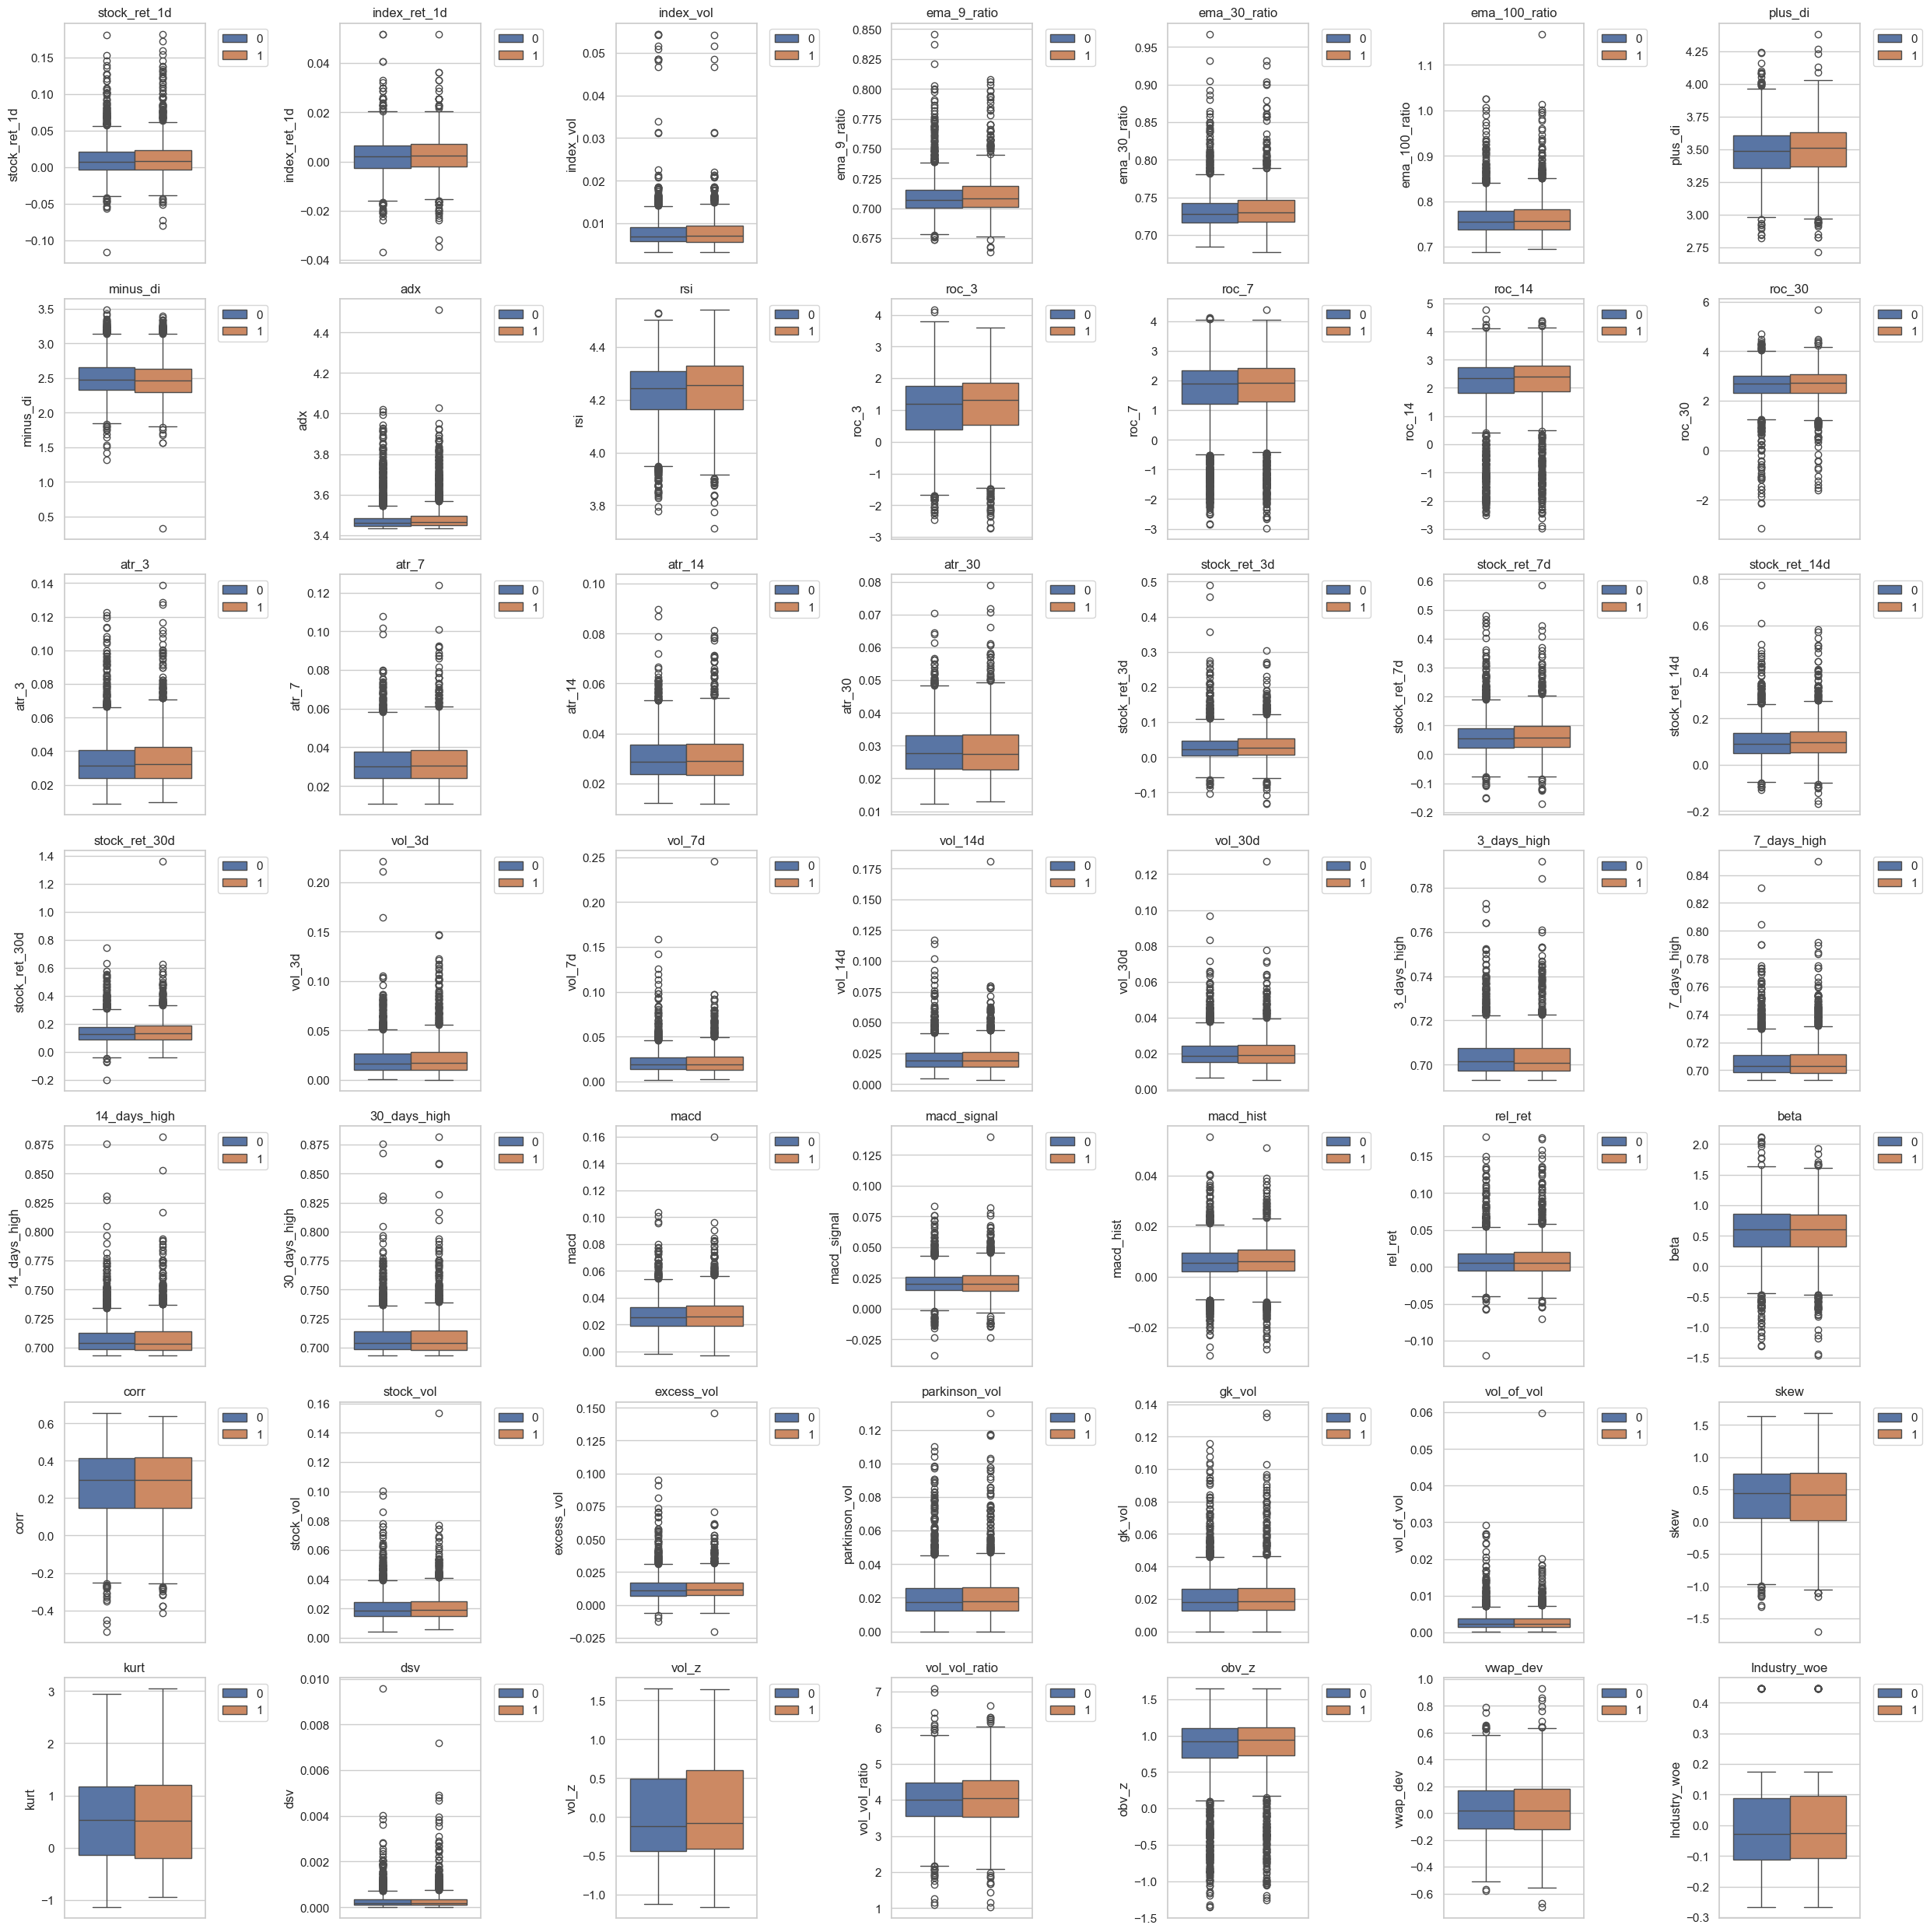

In [95]:
fig, axes = plt.subplots(7, 7, figsize=(25, 25))
axes = axes.flatten()

# Assuming you have a categorical column for hue (replace 'your_hue_column' with actual column name)
hue_column = 'result'  # or whatever categorical column you want to use for hue

for i, col in enumerate(columns):
    if i < len(axes):
        sns.boxplot(data=df_log, y=col, hue=hue_column, ax=axes[i])
        axes[i].set_title(col)
        axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

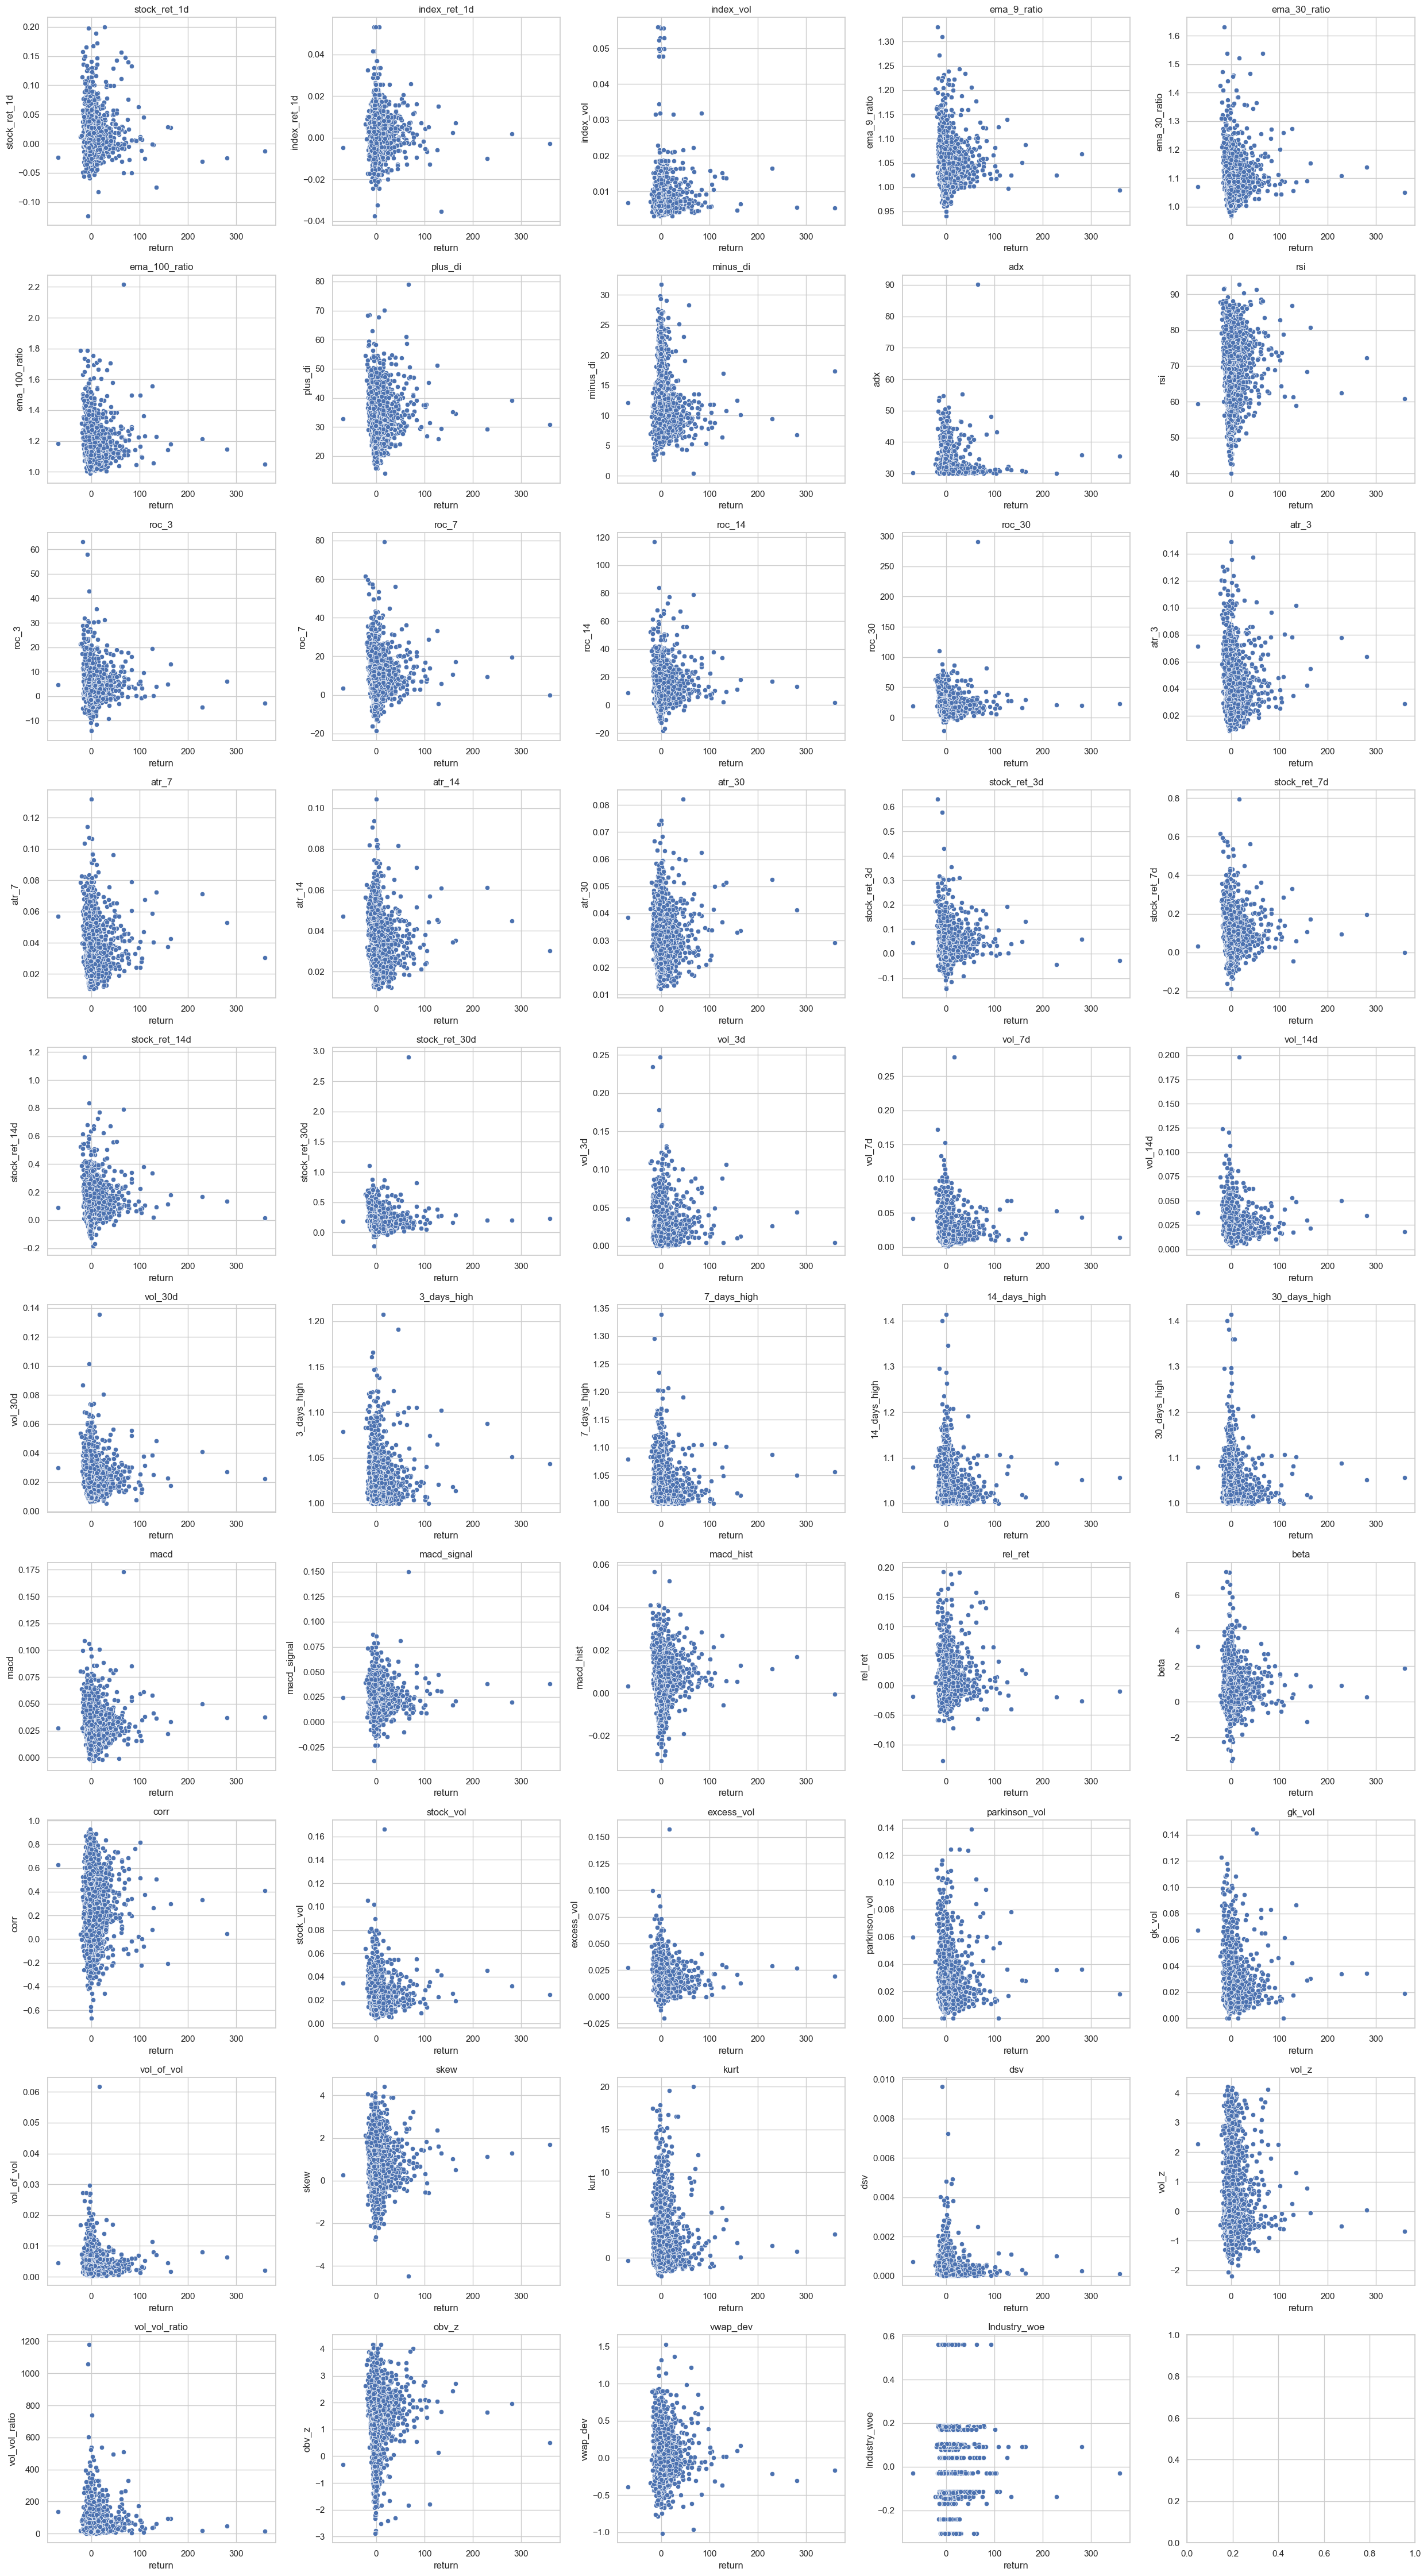

In [ ]:
fig, axes = plt.subplots(10, 5, figsize=(25, 45))
axes = axes.flatten()

for i, col in enumerate(columns):
    if i < len(axes):
        sns.scatterplot(data=df, y=col, x="return" , ax=axes[i])
        axes[i].set_title(col)

plt.tight_layout()
plt.show()

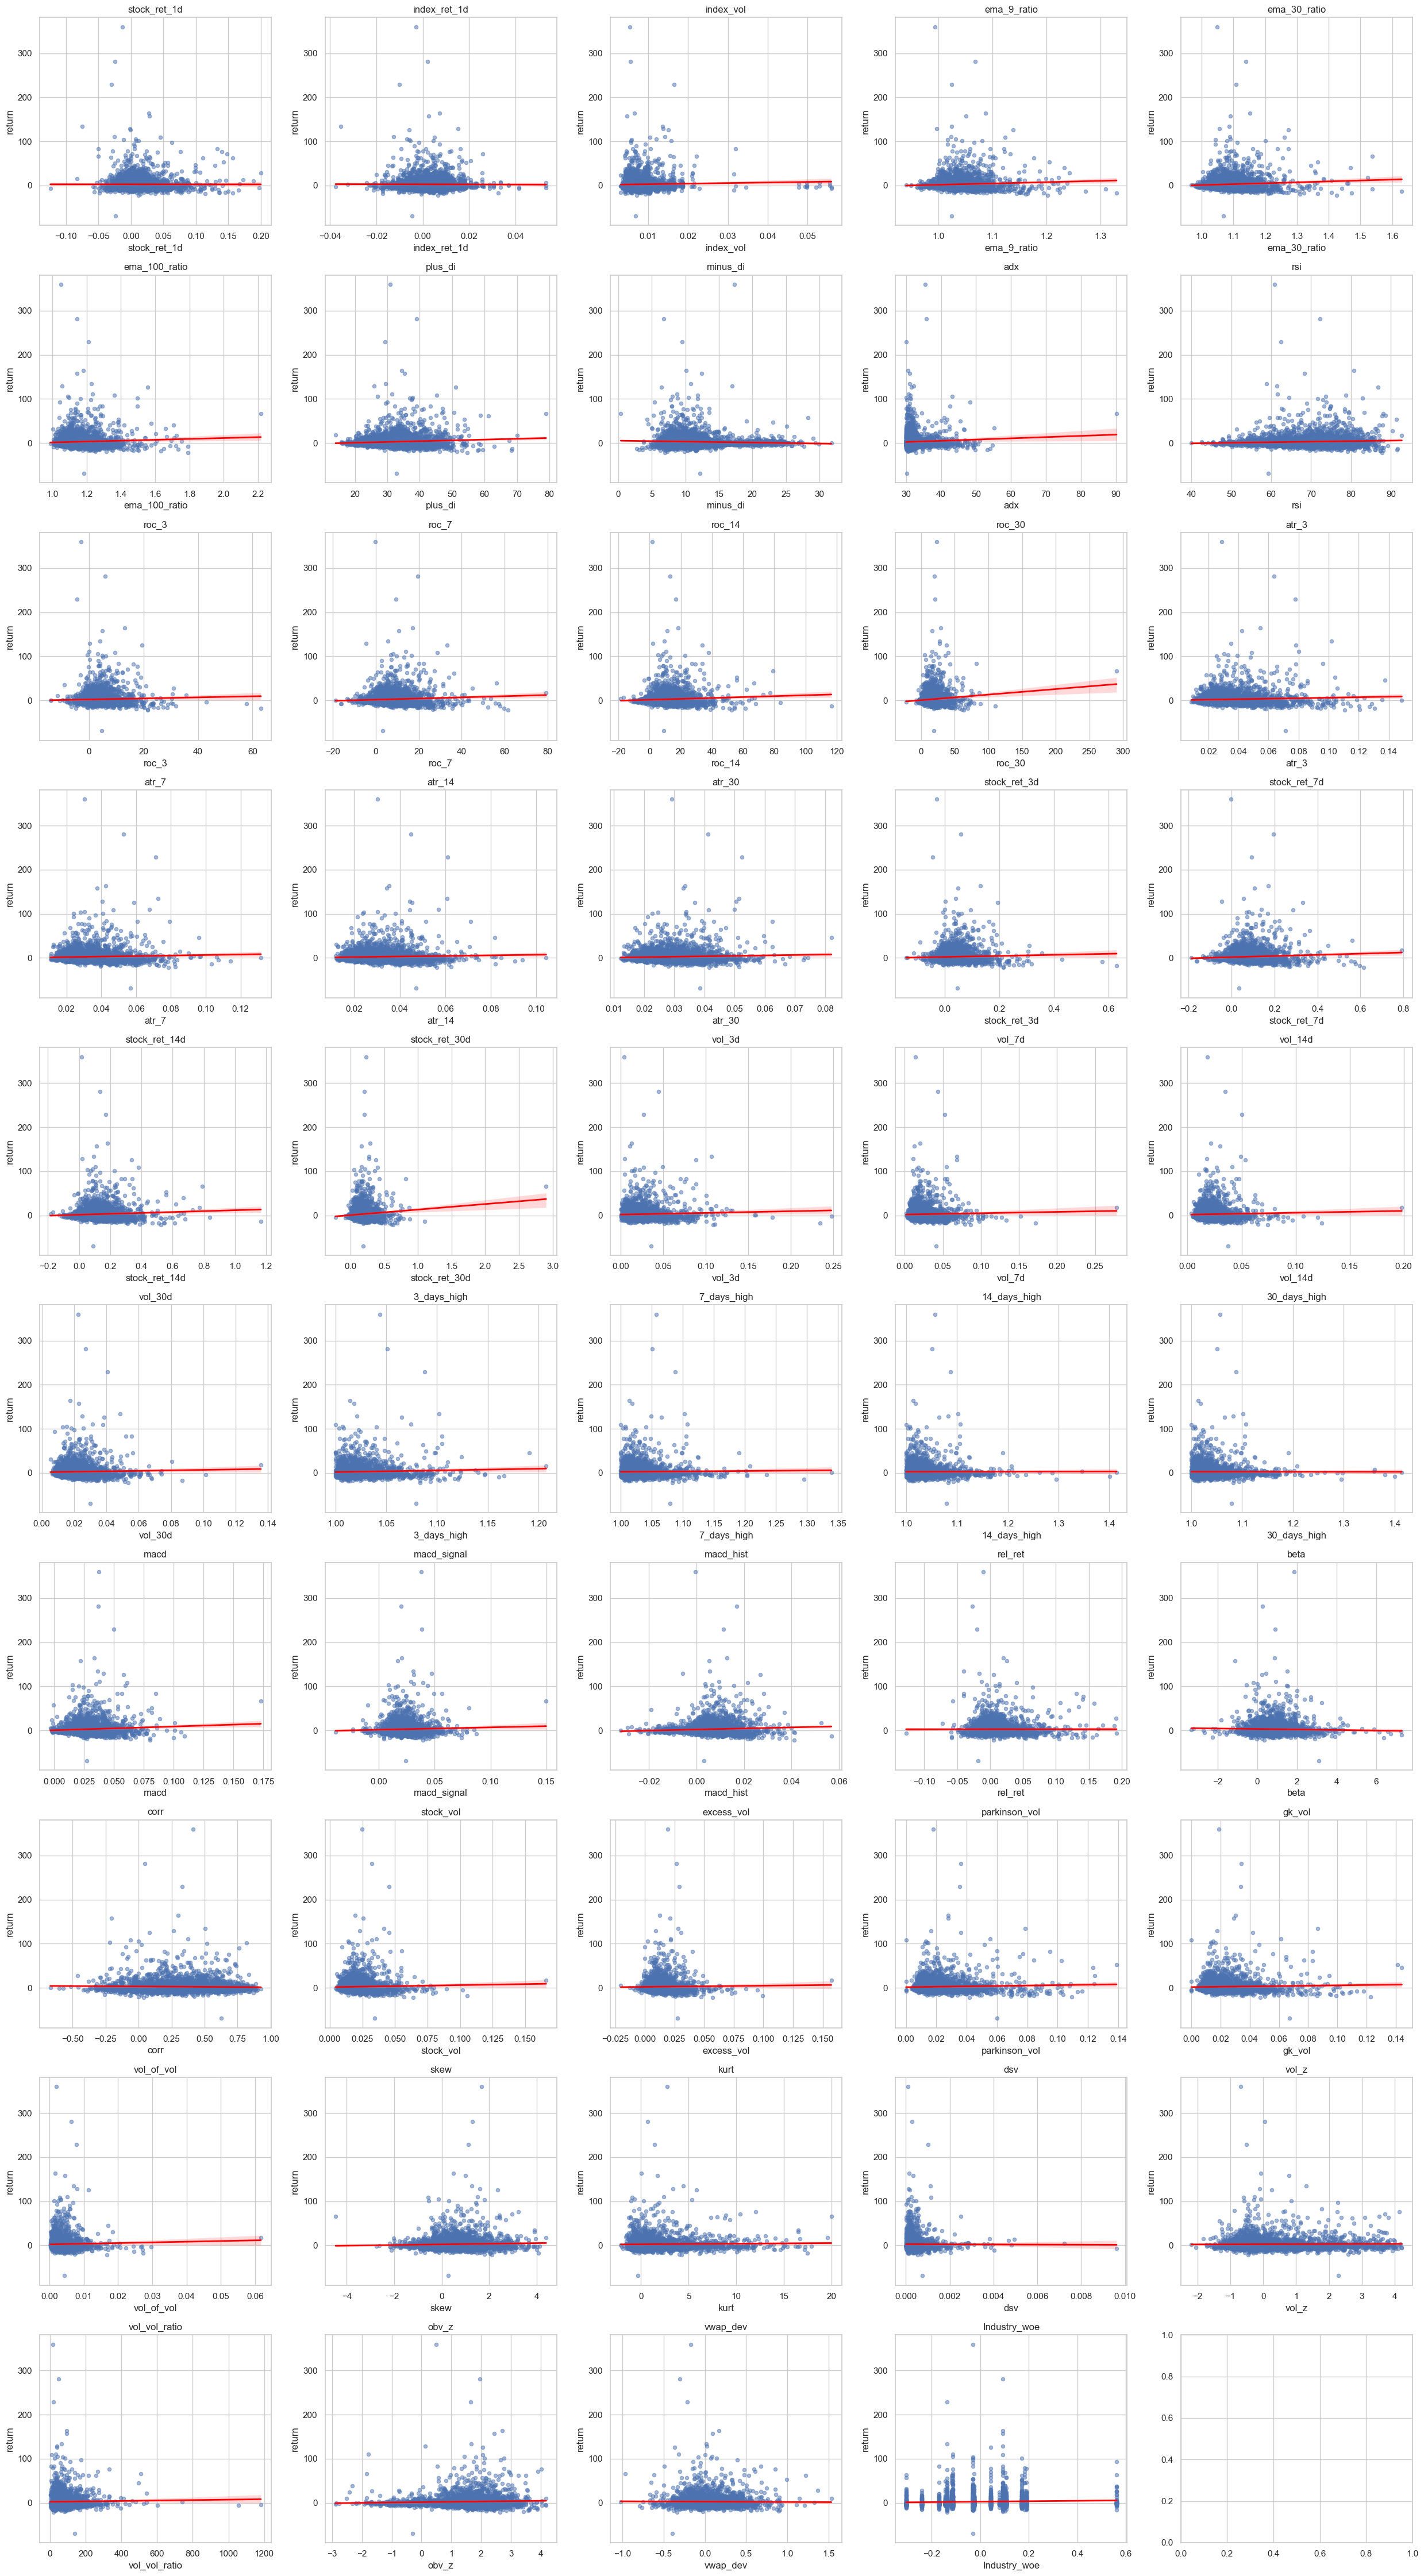

In [6]:
fig, axes = plt.subplots(10, 5, figsize=(25, 45))
axes = axes.flatten()

for i, col in enumerate(columns):
    if i < len(axes):
        sns.regplot(data=df, x=col, y="return", ax=axes[i], 
                   scatter_kws={'alpha':0.5, 's':20}, 
                   line_kws={'color':'red', 'linewidth':2})
        axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [13]:
df

,Symbol,entry_date,entry_price,exit_date,exit_price,return,Close,stock_ret_1d,Index_Close,index_ret_1d,...,dsv,vol_z,vol_vol_ratio,obv_z,vwap_dev,result,Industry,kmeans_cluster,hmm_cluster,Industry_woe
0,ABB,2016-04-01,1130.375488,2016-05-04,1072.873291,-5.087000,1130.375488,0.009983,7713.049805,-0.003276,...,0.000249,1.528192,78.290163,2.057573,0.066625,0,Capital Goods,2.0,1.0,0.092264
1,ABB,2017-04-11,1267.503418,2017-05-23,1273.588867,0.480113,1267.503418,0.029695,9237.000000,0.006050,...,0.000101,-0.244947,71.118903,2.087195,0.314671,1,Capital Goods,2.0,0.0,0.092264
2,ABB,2018-01-15,1330.367676,2018-02-19,1306.259766,-1.812124,1330.367676,0.025037,10741.549805,0.005645,...,0.000050,1.770258,192.689483,2.686783,0.220293,0,Capital Goods,2.0,0.0,0.092264
3,ABB,2018-09-06,1142.333374,2018-10-03,1253.569824,9.737652,1142.333374,0.021961,11536.900391,0.005224,...,0.000115,-0.088891,78.644890,0.792242,0.116395,1,Capital Goods,2.0,0.0,0.092264
4,ABB,2019-04-10,1217.739868,2019-05-09,1225.911133,0.671019,1217.739868,-0.019029,11584.299805,-0.007509,...,0.000076,-0.588970,35.372286,1.555094,-0.154695,1,Capital Goods,2.0,0.0,0.092264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3664,ZYDUSLIFE,2023-04-18,504.088043,2023-05-02,505.113983,0.203524,504.088043,0.027485,17660.150391,-0.002637,...,0.000011,2.308264,236.073903,1.461623,0.484949,1,Healthcare,0.0,2.0,-0.119259
3665,ZYDUSLIFE,2023-06-21,547.276001,2023-08-28,625.555908,14.303552,547.276001,0.007284,18856.849609,0.002134,...,0.000092,-0.071581,79.290502,2.074164,0.092758,1,Healthcare,0.0,2.0,-0.119259
3666,ZYDUSLIFE,2023-08-29,623.238342,2023-08-30,619.441406,-0.609227,623.238342,-0.003705,19342.650391,0.001896,...,0.000125,-0.708708,67.572598,-0.570426,-0.152031,0,Healthcare,0.0,2.0,-0.119259
3667,ZYDUSLIFE,2023-11-09,604.007141,2024-04-12,948.886414,57.098541,604.007141,-0.020393,19395.300781,-0.002479,...,0.000140,0.554319,92.705143,2.027133,-0.284898,1,Healthcare,0.0,2.0,-0.119259


In [15]:
df["entry_price"].describe()

count      3669.000000
mean       1915.539551
std        7228.501953
min           3.948320
25%         174.261047
50%         538.509338
75%        1389.445923
max      150485.734375
Name: entry_price, dtype: float64

In [6]:
filtered_df = df[df["entry_price"] < 10000].copy()
filtered_df

,Symbol,entry_date,entry_price,exit_date,exit_price,return,Close,stock_ret_1d,rsi,adx,...,volatility_of_volatility,dsv,vol_z,vol_vol_ratio,obv_z,vwap_dev,result,Industry,hmm_cluster,Industry_woe
2396,NMDC,2016-03-09,13.149165,2016-04-28,13.738341,4.480711,13.149165,-0.015344,75.574806,33.866604,...,0.004685,0.000438,-0.943376,13.231202,1.863594,0.137517,1,Metals & Mining,0.0,0.171921
1419,HINDALCO,2016-03-21,80.699150,2016-03-30,82.575851,2.325553,80.699150,0.009390,66.985118,30.847063,...,0.004331,0.000358,-0.152065,33.855358,0.968967,0.063425,1,Metals & Mining,3.0,0.171921
3240,TATASTEEL,2016-03-21,22.325666,2016-05-05,24.403414,9.306541,22.325666,0.004467,73.931740,30.156950,...,0.008066,0.000155,-0.579234,35.126138,1.071643,0.016532,1,Metals & Mining,3.0,0.171921
598,BHARTIARTL,2016-03-22,299.554504,2016-04-01,286.365204,-4.402972,299.554504,-0.007776,68.502922,30.521119,...,0.002222,0.000175,0.457509,83.115273,1.333358,0.015242,0,Telecommunication,3.0,-0.170878
2815,RELIANCE,2016-03-22,229.608643,2016-03-28,223.593719,-2.619641,229.608643,0.010171,67.560319,30.172319,...,0.002951,0.000280,0.116702,80.890779,1.781608,0.113989,0,Oil Gas & Consumable Fuels,3.0,0.041870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1692,INDIGO,2025-08-27,6050.000000,2025-08-28,5727.000000,-5.338843,6050.000000,0.000000,57.705115,30.314948,...,0.000636,0.000106,3.992301,603.398978,0.451727,0.000000,0,Services,1.0,-0.240706
3580,VMM,2025-08-27,153.139999,2025-09-02,146.330002,-4.446910,153.139999,0.000000,68.060884,31.580026,...,0.001744,0.000392,1.153450,218.252956,2.544196,0.000000,0,Consumer Services,1.0,0.189966
3360,TITAN,2025-08-29,3628.800049,2025-09-15,3534.100098,-2.609677,3628.800049,-0.002447,64.093506,31.060234,...,0.001865,0.000062,-0.379968,97.851273,1.078735,0.072640,0,Consumer Durables,1.0,0.183092
2209,MFSL,2025-08-29,1602.199951,2025-09-04,1566.000000,-2.259390,1602.199951,-0.004041,53.859737,30.395963,...,0.001349,0.000116,-0.450856,49.298656,0.452576,-0.124731,0,Financial Services,1.0,-0.029508


In [7]:
filtered_df["buy_quantity"] = (10000/filtered_df["entry_price"]).astype(int)

In [8]:
filtered_df["absolute_return"] = (filtered_df["exit_price"] - filtered_df["entry_price"] ) * filtered_df["buy_quantity"]

Text(0, 0.5, 'Cumulative Returns ($)')

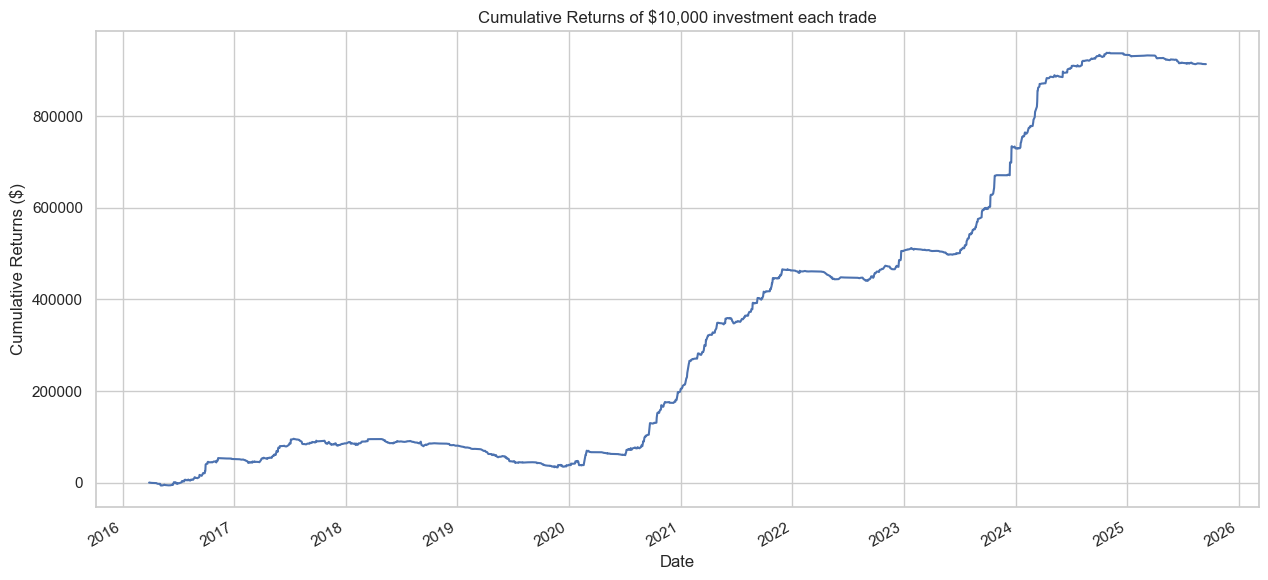

In [9]:
filtered_df.groupby("exit_date")["absolute_return"].sum().sort_index().cumsum().plot(figsize=(15,7), title="Cumulative Returns of $10,000 investment each trade")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns ($)")

In [10]:
grouped_df = filtered_df.groupby(["exit_date","hmm_cluster"]).agg({"absolute_return":"sum"}).reset_index()

In [11]:
grouped_df["cumulative_return"]=grouped_df["absolute_return"].cumsum()

In [12]:
import plotly.graph_objects as go

<Axes: xlabel='exit_date', ylabel='cumulative_return'>

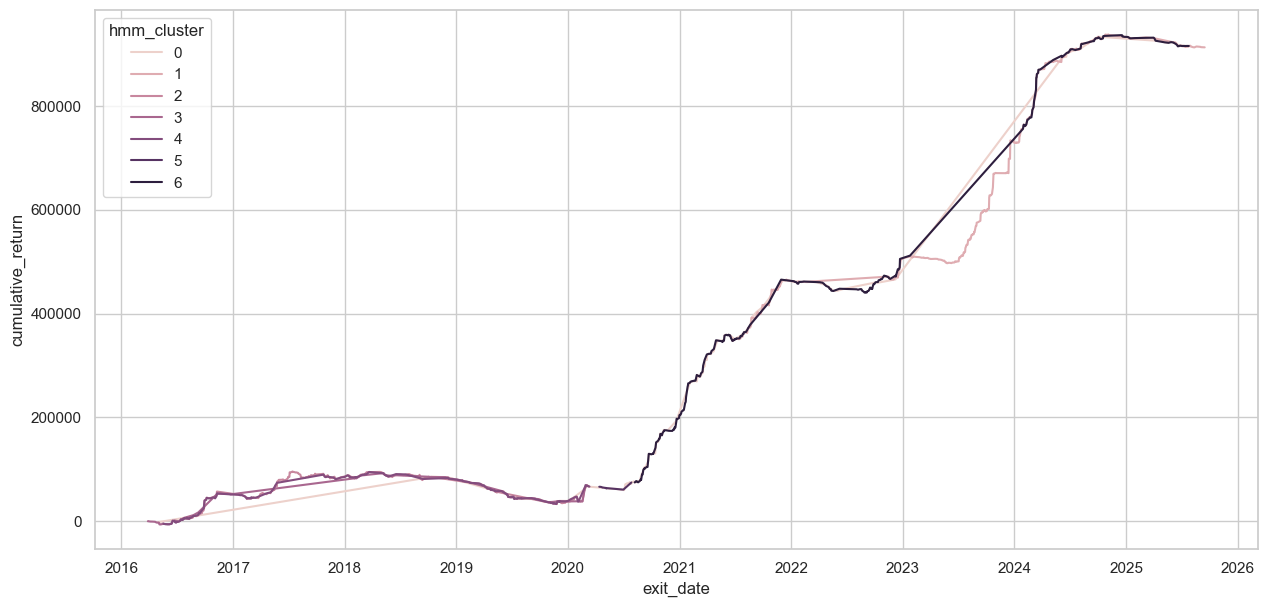

In [13]:
plt.figure(figsize=(15,7))
sns.lineplot(data=grouped_df, x="exit_date", y="cumulative_return", hue="hmm_cluster")

In [14]:
grouped_df["cluster_change"] = grouped_df["hmm_cluster"].ne(grouped_df["hmm_cluster"].shift()).cumsum()

fig = go.Figure()

# Add a line for each continuous cluster segment
for _, seg in grouped_df.groupby("cluster_change"):
    fig.add_trace(go.Scatter(
        x=seg["exit_date"],
        y=seg["cumulative_return"],
        mode="lines",
        line=dict(width=2),
        name=f"Cluster {int(seg['hmm_cluster'].iloc[0])}"
    ))

fig.update_layout(
    title="Cumulative Return (Cluster-Colored)",
    xaxis_title="Exit Date",
    yaxis_title="Cumulative Return",
    legend_title="hmm_cluster",
    height=1000,
)

fig.show()

In [15]:
grouped_df

,exit_date,hmm_cluster,absolute_return,cumulative_return,cluster_change
0,2016-03-28,3.0,-258.641693,-258.641693,1
1,2016-03-30,3.0,230.834267,-27.807426,1
2,2016-04-01,3.0,-452.601593,-480.409019,1
3,2016-04-06,3.0,-372.920265,-853.329285,1
4,2016-04-12,3.0,-96.466064,-949.795349,1
...,...,...,...,...,...
1731,2025-09-01,1.0,-148.650482,914209.388143,785
1732,2025-09-02,1.0,-442.649841,913766.738302,785
1733,2025-09-04,1.0,-217.199707,913549.538595,785
1734,2025-09-11,1.0,-119.000000,913430.538595,785


In [16]:
grouped_df["result"] = np.where(grouped_df["absolute_return"]>0, 1, 0)

In [25]:
grouped_df.groupby("hmm_cluster").agg({"result": lambda x: (x==1).sum() / (x==0).sum()}).sort_values(by="result", ascending=False)

,result
hmm_cluster,
6.0,1.057325
1.0,0.933054
0.0,0.900000
4.0,0.726496
2.0,0.613333
3.0,0.582278
5.0,0.272727


In [23]:
grouped_df["win_loss_ratio"] = grouped_df.groupby("hmm_cluster")["result"].transform(lambda x: (x==1).sum() / (x==0).sum())
grouped_df

,exit_date,hmm_cluster,absolute_return,cumulative_return,cluster_change,result,win_loss_ratio
0,2016-03-28,3.0,-258.641693,-258.641693,1,0,0.582278
1,2016-03-30,3.0,230.834267,-27.807426,1,1,0.582278
2,2016-04-01,3.0,-452.601593,-480.409019,1,0,0.582278
3,2016-04-06,3.0,-372.920265,-853.329285,1,0,0.582278
4,2016-04-12,3.0,-96.466064,-949.795349,1,0,0.582278
...,...,...,...,...,...,...,...
1731,2025-09-01,1.0,-148.650482,914209.388143,785,0,0.933054
1732,2025-09-02,1.0,-442.649841,913766.738302,785,0,0.933054
1733,2025-09-04,1.0,-217.199707,913549.538595,785,0,0.933054
1734,2025-09-11,1.0,-119.000000,913430.538595,785,0,0.933054


In [24]:
grouped_df.sample(10)

,exit_date,hmm_cluster,absolute_return,cumulative_return,cluster_change,result,win_loss_ratio
1436,2024-01-19,1.0,874.256607,742155.070573,619,1,0.933054
1219,2022-10-14,6.0,1318.632935,464240.797464,597,1,1.057325
973,2021-05-31,0.0,1502.420380,359137.168661,484,1,0.900000
178,2017-03-07,2.0,-216.465042,45145.623988,108,0,0.613333
395,2018-05-16,2.0,-449.958984,87950.890000,183,0,0.613333
1419,2023-12-22,1.0,-1204.372162,732039.079843,619,0,0.933054
1701,2025-07-02,6.0,192.684814,915905.104467,774,1,1.057325
1055,2021-08-24,1.0,-126.143188,391435.065366,545,0,0.933054
1147,2022-02-18,0.0,155.763062,460922.301831,578,1,0.900000
867,2020-11-24,0.0,462.601074,175573.516309,434,1,0.900000


<Axes: title={'center': 'Total Returns by HMM Cluster and Result'}, xlabel='hmm_cluster'>

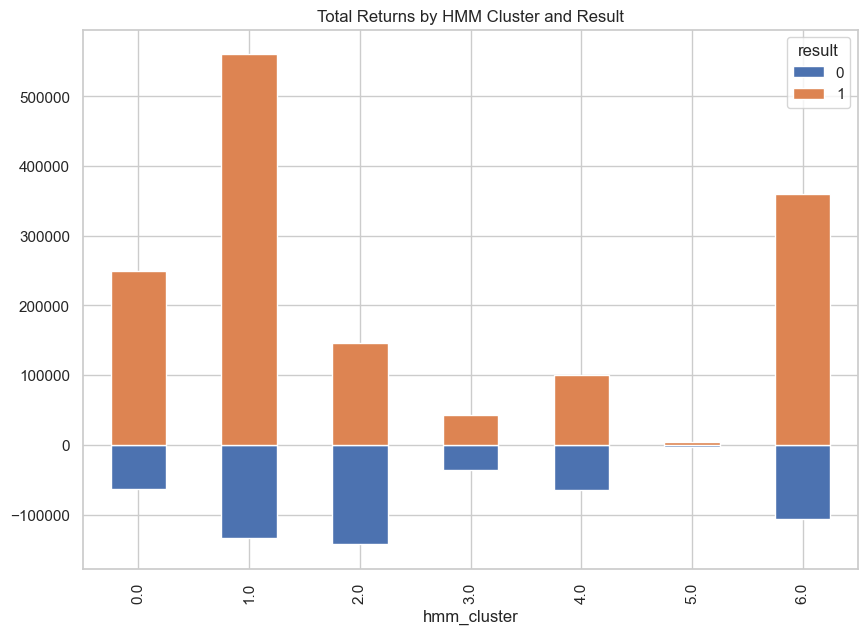

In [ ]:
grouped_df.groupby(["hmm_cluster","result"])["absolute_return"].sum().reset_index().pivot(index="hmm_cluster", columns="result", values="absolute_return").fillna(0).plot(kind="bar", stacked=True, figsize=(10,7), title="Total Returns by HMM Cluster and Result")